**Author: Svenja Gaedcke**  
gaedcke.svenja@mh-hannover.de  
12/2024

In [17]:
%matplotlib inline
import sys
import os
import numpy as np
import pandas as pd
import scanpy as sc
import datetime
import scipy
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import colors

#Read config file
import configparser as config
config = config.ConfigParser()
config.read('./config.ini')
data_path=config['PATHS']["wd"]+"git/"
os.chdir(data_path)

sc.settings.verbosity = 0         # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()
sc.set_figure_params(scanpy=True, dpi=100, dpi_save=150,
                         frameon=True, vector_friendly=True, 
                         fontsize=14, color_map=None, format='pdf',
                         transparent=True )
sc._settings.n_jobs = 5
sc._settings.max_memory = 80 #GB
plt.rcParams['figure.figsize']=(5,5) #rescale figures
sc._settings.savefigs = True

-----
anndata     0.7.8
scanpy      1.9.3
-----
PIL                         9.4.0
anndata2ri                  1.1
asciitree                   NA
asttokens                   NA
backcall                    0.2.0
beta_ufunc                  NA
binom_ufunc                 NA
bottleneck                  1.3.5
cffi                        1.15.1
cloudpickle                 2.2.1
colorama                    0.4.6
comm                        0.1.2
cycler                      0.10.0
cython_runtime              NA
cytoolz                     0.12.0
dask                        2023.4.1
dateutil                    2.8.2
debugpy                     1.5.1
decorator                   5.1.1
defusedxml                  0.7.1
entrypoints                 0.4
executing                   0.8.3
fasteners                   NA
h5py                        3.1.0
hypergeom_ufunc             NA
igraph                      0.9.10
importlib_resources         NA
ipykernel                   6.19.2
ipython_genutils    

In [18]:
import rpy2.rinterface_lib.callbacks
import logging
from rpy2.robjects import pandas2ri
import anndata2ri
import rpy2.robjects as robjects

# Ignore R warning messages
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

# Automatically convert rpy2 outputs to pandas dataframes
pandas2ri.activate()
anndata2ri.activate()
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [19]:
%%R
print(version)
.libPaths( c( "/mnt/dzl_bioinf/exec/R_libs/4.0.0/"  , .libPaths()[2] ) )
# Load all the R libraries we will be using in the notebook
library(scran)        #preprocessing
library(RColorBrewer) #visualization
#library(clusterExperiment) #visualization
library(ggplot2)
library(plyr)
library(MAST)         #differential expression analysis

               _                           
platform       x86_64-conda-linux-gnu      
arch           x86_64                      
os             linux-gnu                   
system         x86_64, linux-gnu           
status                                     
major          4                           
minor          2.0                         
year           2022                        
month          04                          
day            22                          
svn rev        82229                       
language       R                           
version.string R version 4.2.0 (2022-04-22)
nickname       Vigorous Calisthenics       


# Read Data

In [20]:
datapath = data_path[:-4]+"N4703m-N4706m/02_DataProcessing/05_hto_demultiplexing/"
results_path = "results/"
results_file = 'results/scAnalyse_preprocessed_Spleen.h5ad'  
filenames = ["N4703ms1/N4703ms1_10xCounts/", "N4703ms2/N4703ms2_10xCounts/",
             "N4703ms3/N4703ms3_10xCounts/", "N4703ms4/N4703ms4_10xCounts/", 
             "N4703ms5/N4703ms5_10xCounts", "N4703ms6/N4703ms6_10xCounts/"
             ]

sample_string = ["N4703ms1", "N4703ms2", "N4703ms3", "N4703ms4", "N4703ms5", "N4703ms6"]
sample_id = ["0","1","2","3","4","5","6"]
group = ["WT","WT","NotchKO","NotchKO","RbpjKO", "RbpjKO"]
batch = ["batch_0","batch_0","batch_0","batch_0","batch_0","batch_0"]

In [21]:
#read first data
print(0, filenames[0])
adata = sc.read_10x_mtx(datapath+filenames[0], var_names="gene_symbols",
                        cache=True, gex_only =False)
adata.obs["sample"] = [sample_string[0]]*adata.n_obs
adata.obs["batch"] = [batch[0]]*adata.n_obs
adata.obs["group"] = [group[0]]*adata.n_obs
adata.var_names_make_unique() 
adata

# read additional data
for index,filepath in enumerate(filenames[1:], start=1):
    print(index, filepath)
    adata_tmp = sc.read_10x_mtx(datapath+filepath, var_names="gene_symbols",
                                cache=True, gex_only =False)
    adata_tmp.obs["sample"] = [sample_string[index]]*adata_tmp.n_obs
    adata_tmp.obs["batch"] = [batch[index]]*adata_tmp.n_obs
    adata_tmp.var_names_make_unique() 
    adata_tmp.obs["sample_id"] = [str(index)]*adata_tmp.n_obs    
    adata_tmp.obs["group"] = [group[index]]*adata_tmp.n_obs
    
    #concatenate to main data
    adata = adata.concatenate(adata_tmp, batch_key='sample_id')
    adata.obs.drop(columns=['sample_id'], inplace=True)

0 N4703ms1/N4703ms1_10xCounts/
1 N4703ms2/N4703ms2_10xCounts/


/mnt/dzl_bioinf/exec/miniconda/miniconda3/envs/scRNA2023/lib/python3.9/site-packages/anndata/_core/anndata.py:1755: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


2 N4703ms3/N4703ms3_10xCounts/


/mnt/dzl_bioinf/exec/miniconda/miniconda3/envs/scRNA2023/lib/python3.9/site-packages/anndata/_core/anndata.py:1755: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


3 N4703ms4/N4703ms4_10xCounts/


/mnt/dzl_bioinf/exec/miniconda/miniconda3/envs/scRNA2023/lib/python3.9/site-packages/anndata/_core/anndata.py:1755: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


4 N4703ms5/N4703ms5_10xCounts


/mnt/dzl_bioinf/exec/miniconda/miniconda3/envs/scRNA2023/lib/python3.9/site-packages/anndata/_core/anndata.py:1755: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


5 N4703ms6/N4703ms6_10xCounts/


/mnt/dzl_bioinf/exec/miniconda/miniconda3/envs/scRNA2023/lib/python3.9/site-packages/anndata/_core/anndata.py:1755: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


In [22]:
#drop HTO-values from matrix, they were used to differentiate between Alum, OVA, Tol
non_hto_genelist = [name for name in adata.var_names if not name.startswith('HTO-')]
adata = adata[:, non_hto_genelist]

In [23]:
adata

View of AnnData object with n_obs × n_vars = 9818 × 32285
    obs: 'sample', 'batch', 'group'
    var: 'gene_ids', 'feature_types'

&rarr; 25363 cells and 32285 genes in raw dataset

In [24]:
print(adata.obs['sample'].value_counts())

N4703ms4    1867
N4703ms5    1837
N4703ms6    1836
N4703ms3    1787
N4703ms1    1550
N4703ms2     941
Name: sample, dtype: int64


In [25]:
print(data_path+'results/scAnalyse_raw_spleen.h5ad')
adata.write(data_path+'results/scAnalyse_raw_spleen.h5ad')

/mnt/dzl_bioinf/gaedckes/scRNASeq/Macrophagen_AGLimbourg_202310/git/results/scAnalyse_raw_spleen.h5ad


/mnt/dzl_bioinf/exec/miniconda/miniconda3/envs/scRNA2023/lib/python3.9/site-packages/anndata/_core/anndata.py:1222: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/mnt/dzl_bioinf/exec/miniconda/miniconda3/envs/scRNA2023/lib/python3.9/site-packages/anndata/_core/anndata.py:1222: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/mnt/dzl_bioinf/exec/miniconda/miniconda3/envs/scRNA2023/lib/python3.9/site-packages/anndata/_core/anndata.py:1222: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/mnt/dzl_bioinf/exec/miniconda/miniconda3/envs/scRNA2023/lib/python3.9/site-packages/anndata/_core/anndata.py:1222: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c


# Quality controll:

In [26]:
adata.obs['n_counts'] = adata.X.sum(axis=1).A1
mito_genes = adata.var_names.str.startswith('mt-') # get mt genes
adata.obs['percent_mito'] = np.sum(adata[:, mito_genes].X, axis=1).A1 / np.sum(adata.X, axis=1).A1
adata.obs['n_genes'] = (adata.X > 0).sum(1).A1

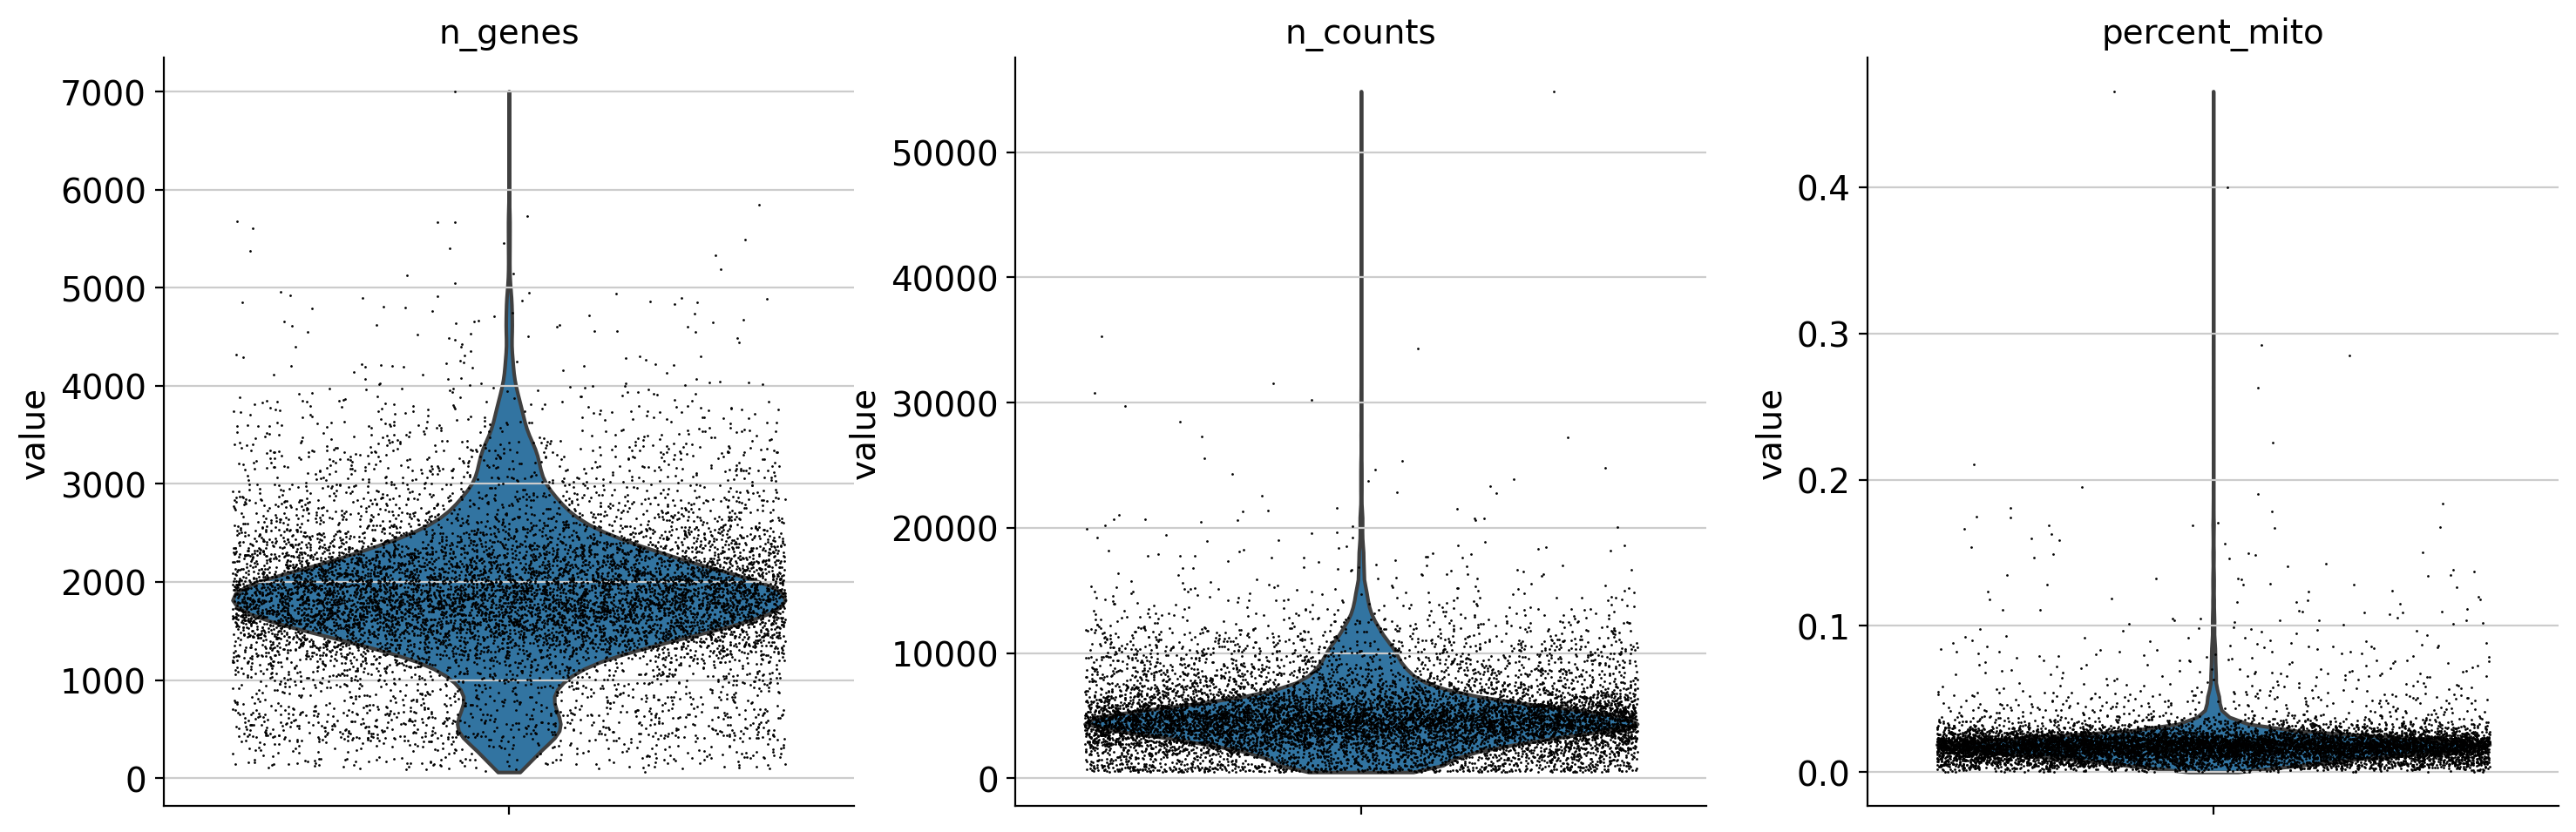

In [27]:
#to find thresholds use:
sc.pl.violin(adata, ['n_genes', 'n_counts', 'percent_mito'],
             jitter=0.4, multi_panel=True)

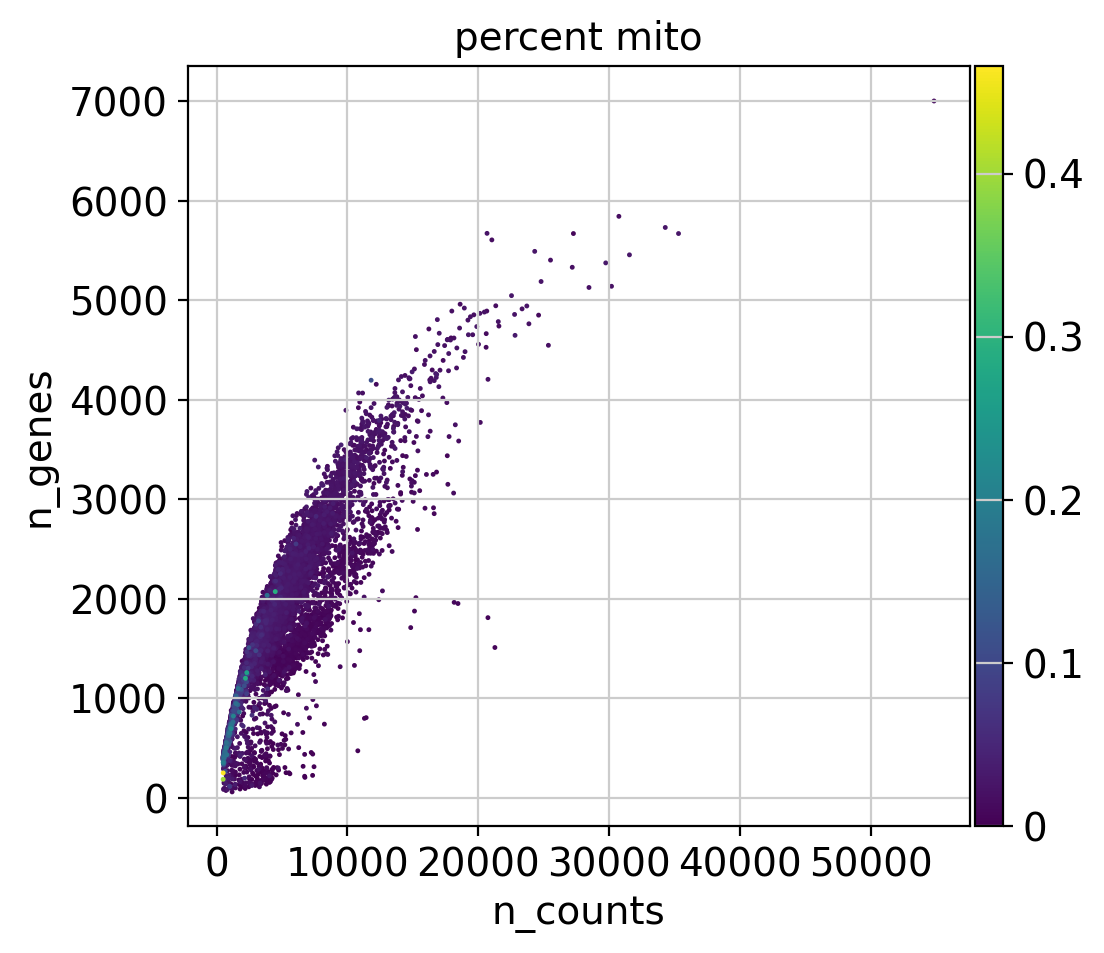

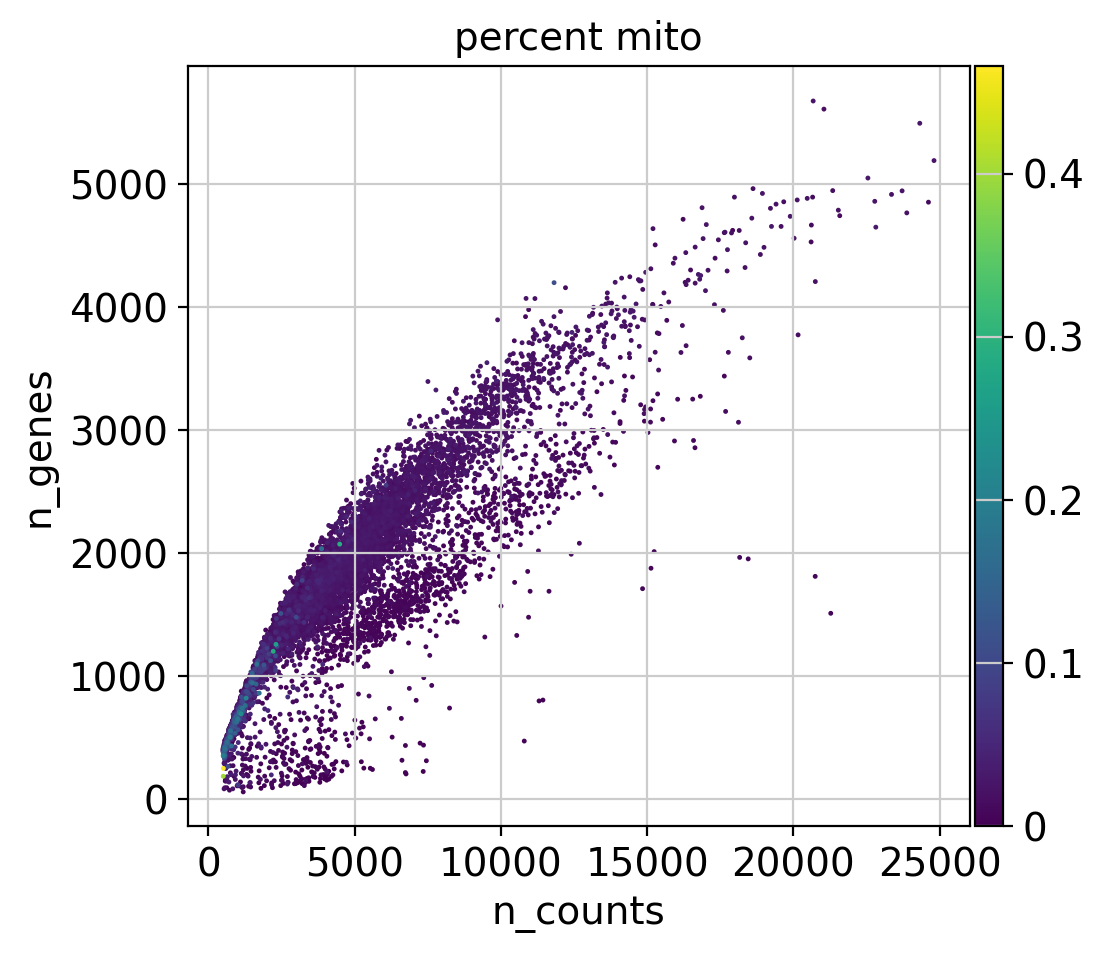

In [28]:
#Data quality summary plots
p1 = sc.pl.scatter(adata, 'n_counts', 'n_genes', color='percent_mito')
p2 = sc.pl.scatter(adata[adata.obs['n_counts']<25000], 'n_counts', 'n_genes', color='percent_mito')

- cells with high mt_percentage have low number of genes and counts &rarr; stressed or dying cells

/tmp/ipykernel_3909992/500904156.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p3 = sb.distplot(adata.obs['n_counts'], kde=False)


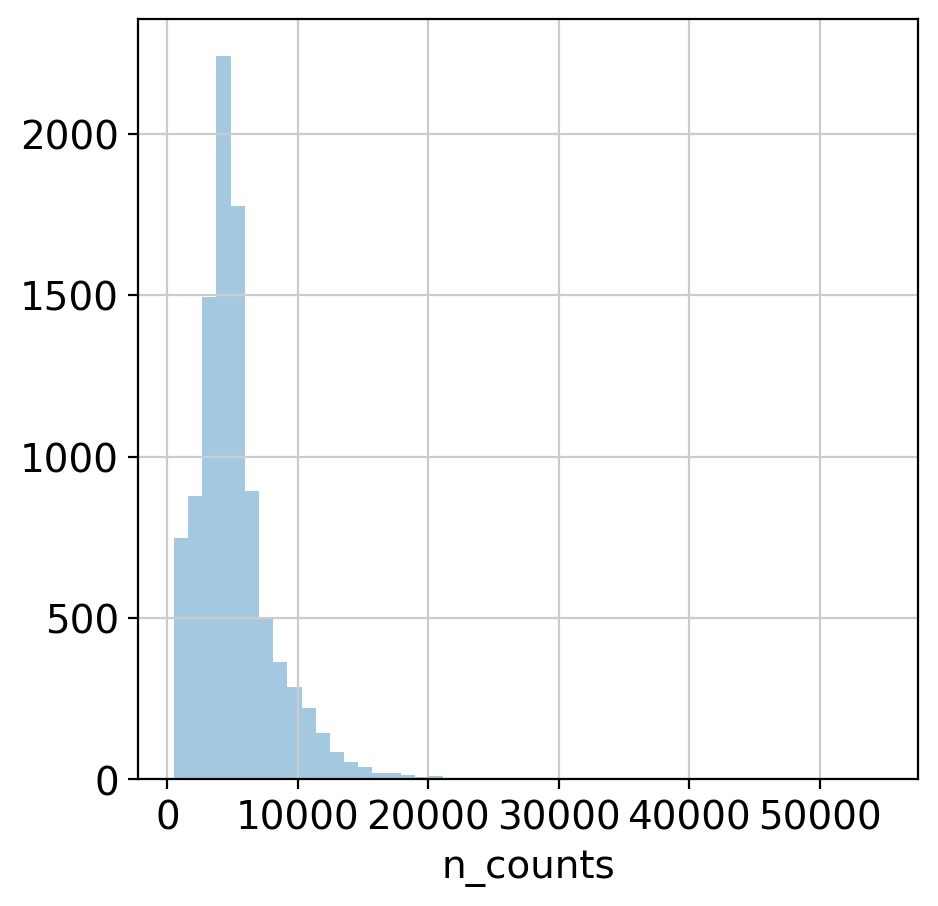

In [29]:
#Thresholding decision: counts
p3 = sb.distplot(adata.obs['n_counts'], kde=False)
plt.show()

-> threshold max. : 20000

/tmp/ipykernel_3909992/3795188172.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)


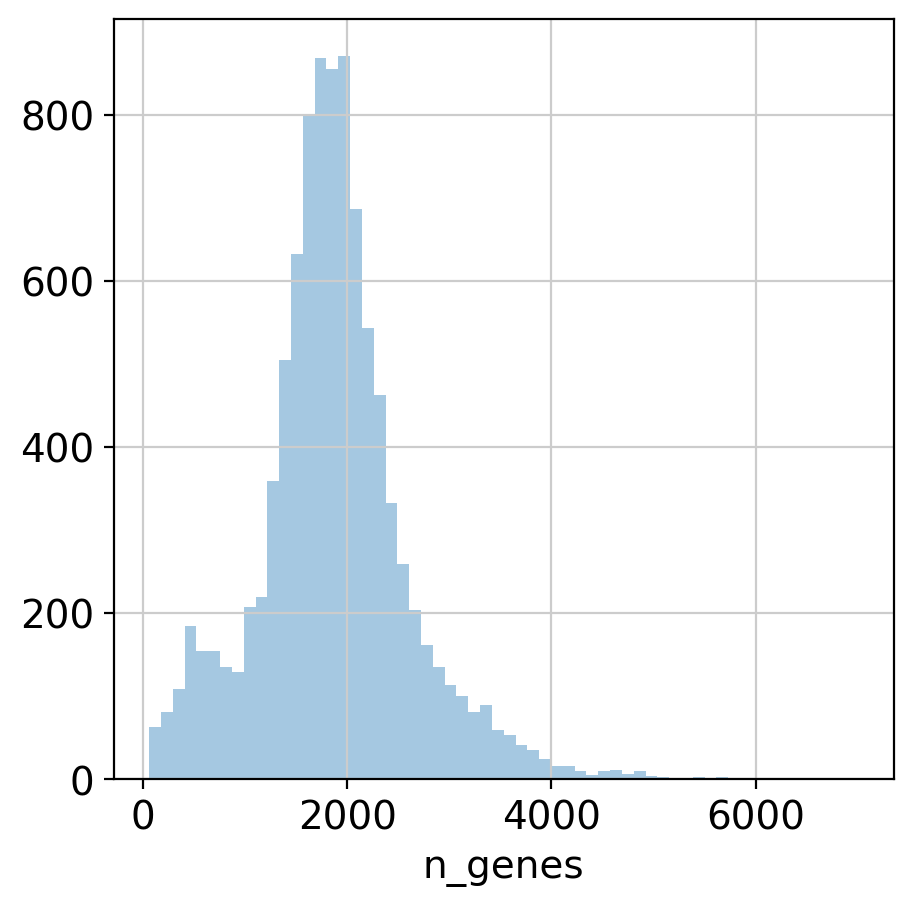

/tmp/ipykernel_3909992/3795188172.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes']<800], kde=False, bins=60)


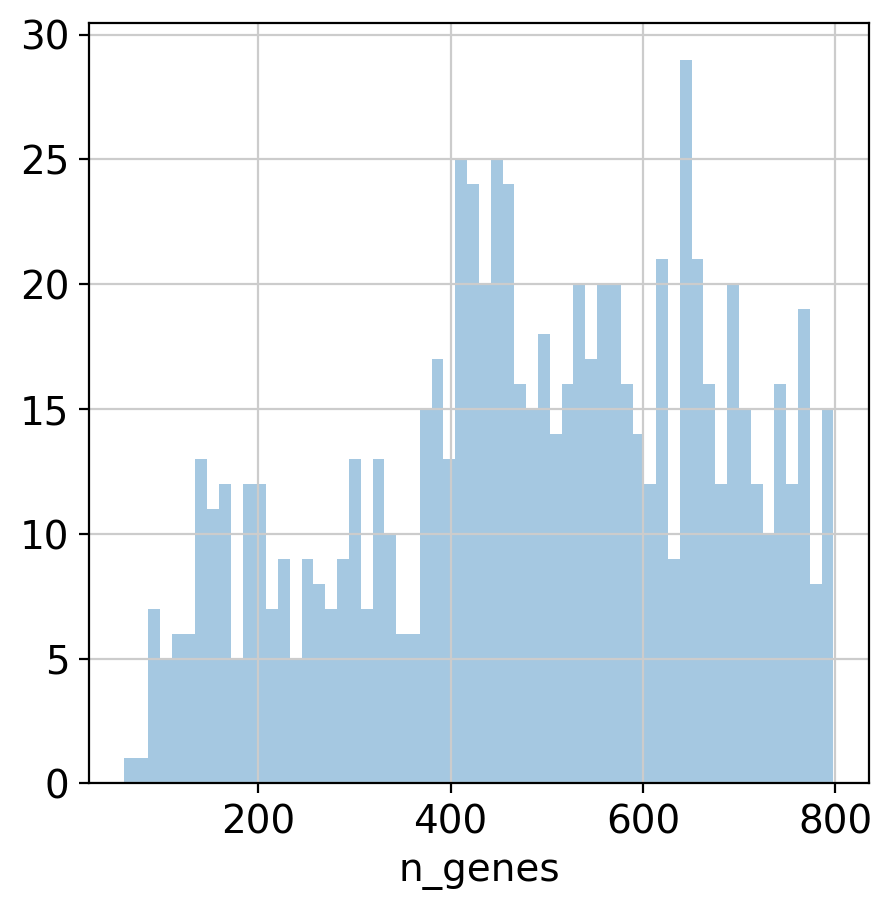

In [30]:
#Thresholding decision: genes
p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)
plt.show()

p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes']<800], kde=False, bins=60)
plt.show()

remove cells with fewer than 300 genes expressed. Below: dying cells or empty droplets with ambient RNA. 

In [31]:
adata

AnnData object with n_obs × n_vars = 9818 × 32285
    obs: 'sample', 'batch', 'group', 'n_counts', 'percent_mito', 'n_genes'
    var: 'gene_ids', 'feature_types'

In [32]:
print(adata[adata.obs.n_counts >= 20000, :].shape[0], " cells were removed with more then 2000 counts")
print(adata[adata.obs.n_genes <= 350, :].shape[0], " cells were removed with less then 350 expressed genes")
print(np.unique(sc.pp.filter_genes(adata, min_cells=5, inplace=False)[0], return_counts=True)[1][0] ,
      " genes were removed that were expressed in less then 5 cells")
print(adata[adata.obs.percent_mito >= 0.05, :].shape[0], " cells were removed with more then 5% mt genes")

36  cells were removed with more then 2000 counts
191  cells were removed with less then 350 expressed genes
15430  genes were removed that were expressed in less then 5 cells
288  cells were removed with more then 5% mt genes


In [33]:
#sc.pp.filter_cells(adata, min_counts = 1200)
sc.pp.filter_cells(adata, max_counts = 20000)
sc.pp.filter_cells(adata, min_genes=350, inplace=True) #remove cell if less then 350 genes in cell expressed
sc.pp.filter_genes(adata, min_cells=5, inplace=True)   #remove gene if less then 5 cells express the gene

adata = adata[adata.obs.percent_mito < 0.05, :]

In [34]:
adata

View of AnnData object with n_obs × n_vars = 9312 × 16799
    obs: 'sample', 'batch', 'group', 'n_counts', 'percent_mito', 'n_genes'
    var: 'gene_ids', 'feature_types', 'n_cells'

## after filtering:

View of AnnData object with n_obs × n_vars = 9312 × 16799
    obs: 'sample', 'batch', 'group', 'n_counts', 'percent_mito', 'n_genes'
    var: 'gene_ids', 'feature_types', 'n_cells'


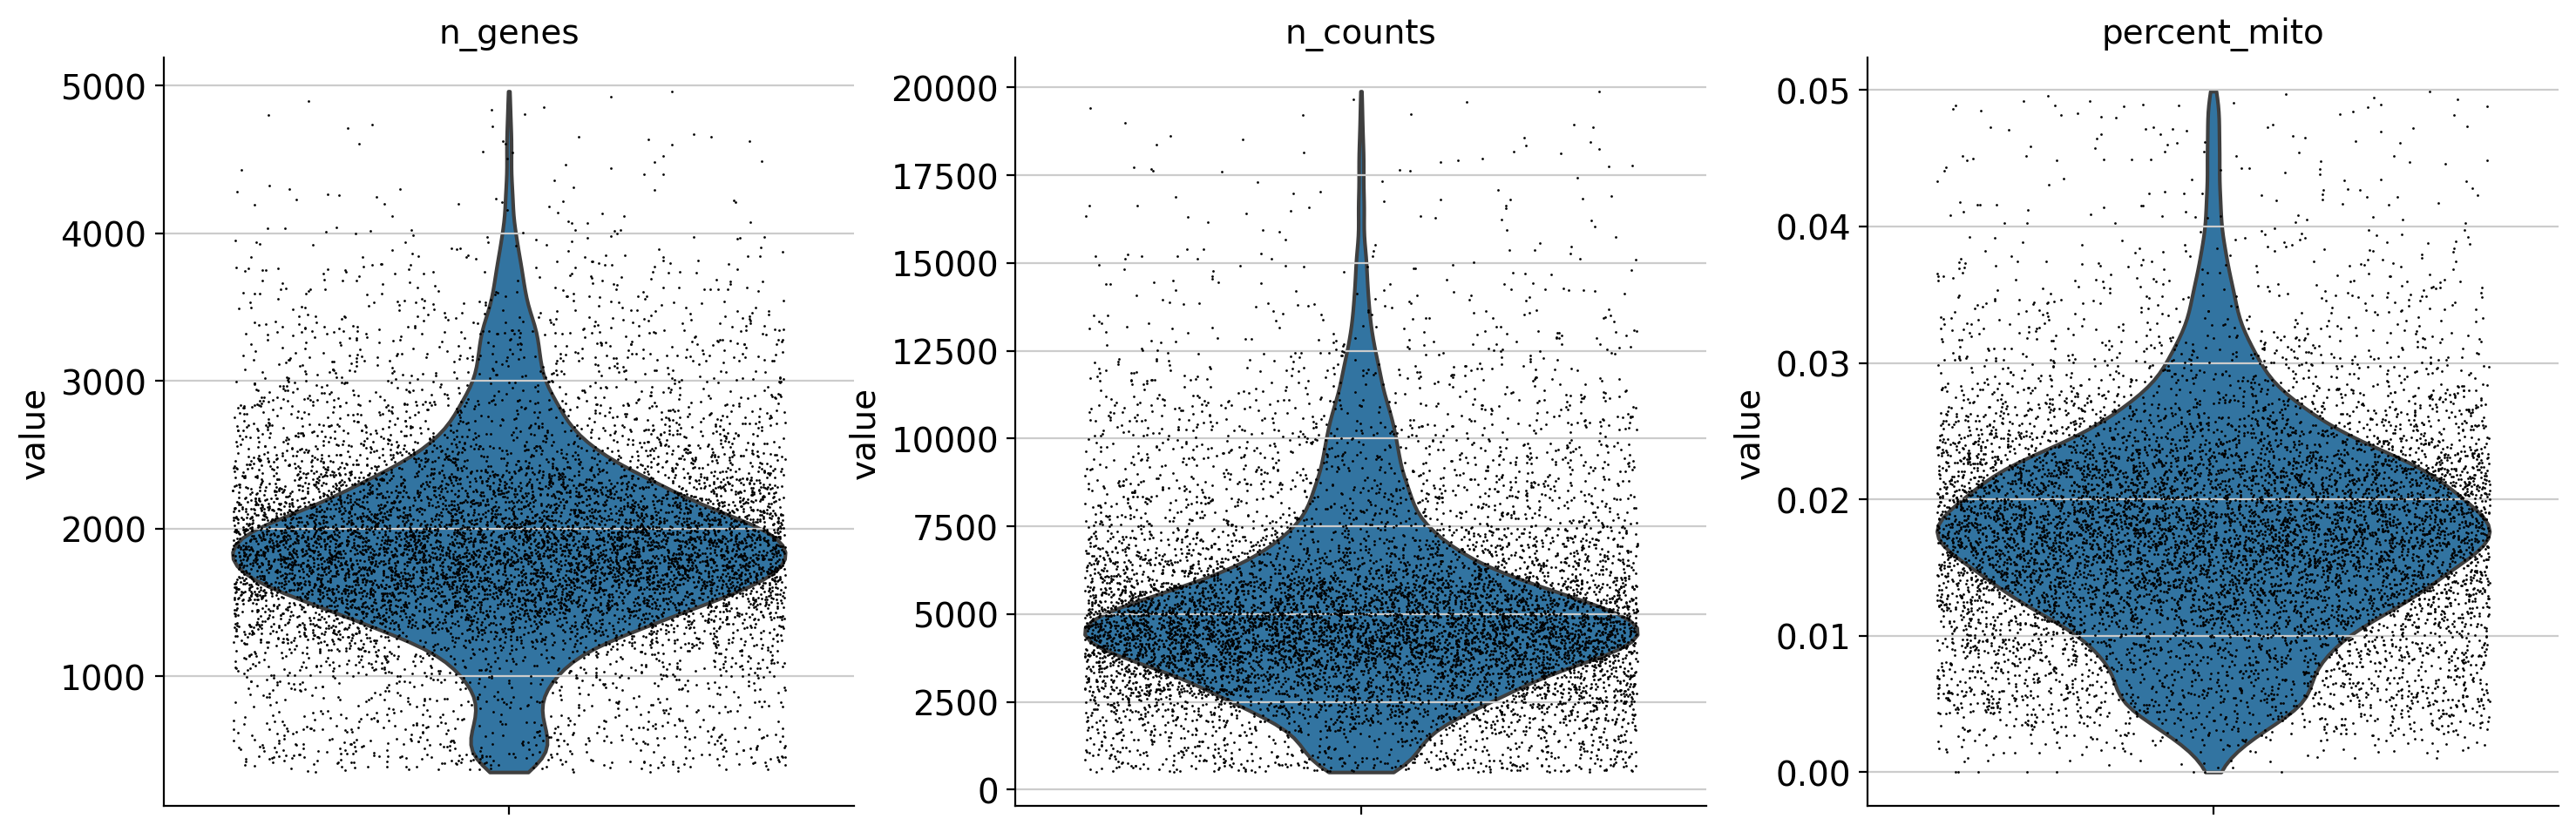

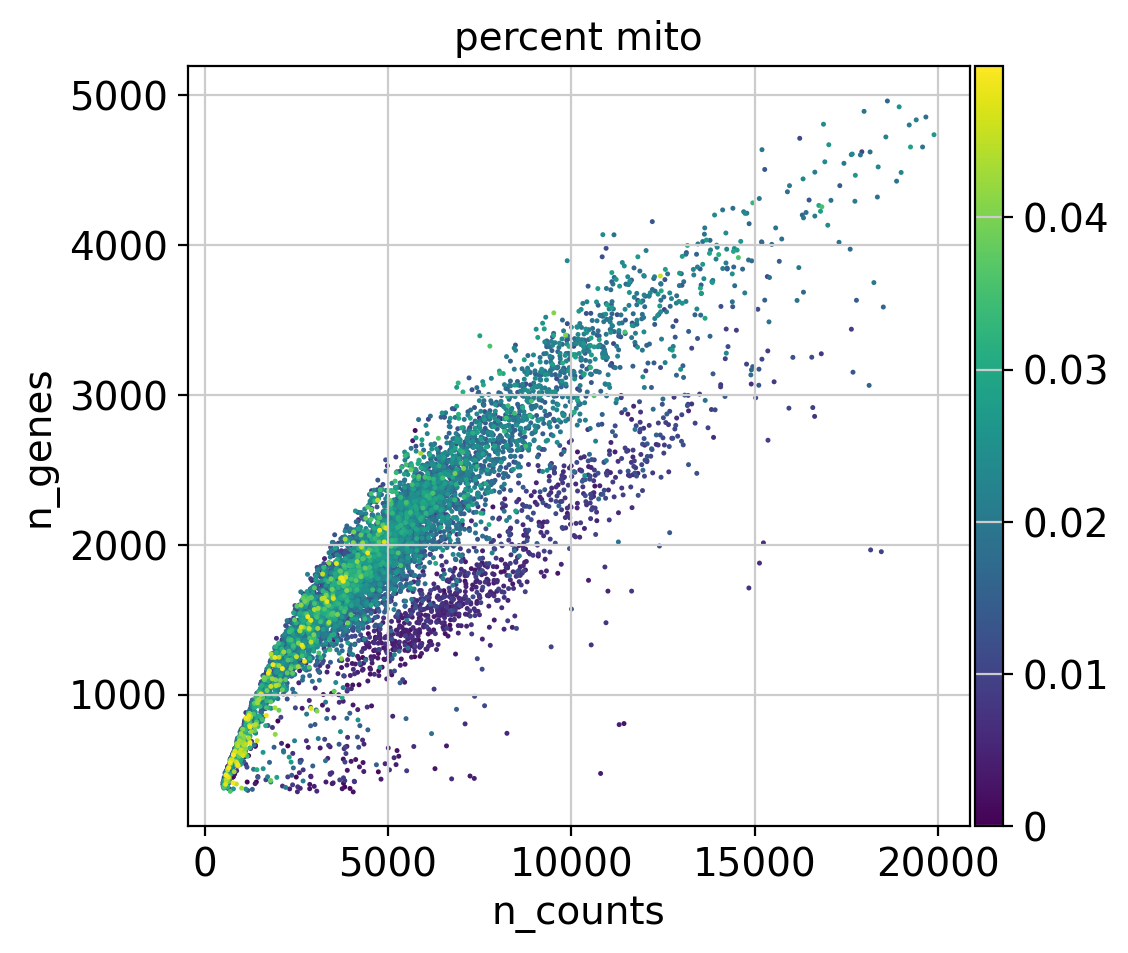

In [35]:
print(adata)
sc.pl.violin(adata, ['n_genes', 'n_counts', 'percent_mito'],jitter=0.4, multi_panel=True)#, groupby="sample")
sc.pl.scatter(adata, x='n_counts', y='n_genes', color="percent_mito")

# Doublet detection - Scrublet


In [36]:
%matplotlib inline
import scrublet as scr

adata.obs['predicted_doublets']= False
adata.obs['doublet_scores']= 0
for s in np.unique(adata.obs["sample"]):
    print(s)
    adt = adata[adata.obs["sample"]==s]
    scrub = scr.Scrublet(adt.X)
    adt.obs['doublet_scores'], adt.obs['predicted_doublets'] = scrub.scrub_doublets()
    scrub.plot_histogram()
    sc.pp.neighbors(adt)
    sc.tl.umap(adt)
    sc.pl.umap(adt, color=['doublet_scores'])
    adata.obs.loc[adata.obs["sample"]==s, "predicted_doublets"] = adt.obs['predicted_doublets']
    adata.obs.loc[adata.obs["sample"]==s, "doublet_scores"] = adt.obs['doublet_scores']
    
del adt

/tmp/ipykernel_3909992/3744380895.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['predicted_doublets']= False


N4703ms1
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.46
Detected doublet rate = 1.0%
Estimated detectable doublet fraction = 26.1%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 3.8%
Elapsed time: 2.1 seconds


/tmp/ipykernel_3909992/3744380895.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adt.obs['doublet_scores'], adt.obs['predicted_doublets'] = scrub.scrub_doublets()
/mnt/dzl_bioinf/exec/miniconda/miniconda3/envs/scRNA2023/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/mnt/dzl_bioinf/exec/miniconda/miniconda3/envs/scRNA2023/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it wil

N4703ms2
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.50
Detected doublet rate = 0.9%
Estimated detectable doublet fraction = 17.3%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 5.3%
Elapsed time: 1.3 seconds


/tmp/ipykernel_3909992/3744380895.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adt.obs['doublet_scores'], adt.obs['predicted_doublets'] = scrub.scrub_doublets()
/mnt/dzl_bioinf/exec/miniconda/miniconda3/envs/scRNA2023/lib/python3.9/site-packages/scanpy/plotting/_utils.py:314: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  pl.show()


...

/tmp/ipykernel_3909992/3744380895.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adt.obs['doublet_scores'], adt.obs['predicted_doublets'] = scrub.scrub_doublets()
/mnt/dzl_bioinf/exec/miniconda/miniconda3/envs/scRNA2023/lib/python3.9/site-packages/scanpy/plotting/_utils.py:314: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  pl.show()


N4703ms5
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.56
Detected doublet rate = 0.3%
Estimated detectable doublet fraction = 15.7%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 1.8%
Elapsed time: 1.8 seconds


/tmp/ipykernel_3909992/3744380895.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adt.obs['doublet_scores'], adt.obs['predicted_doublets'] = scrub.scrub_doublets()
/mnt/dzl_bioinf/exec/miniconda/miniconda3/envs/scRNA2023/lib/python3.9/site-packages/scanpy/plotting/_utils.py:314: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  pl.show()


N4703ms6
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.45
Detected doublet rate = 0.9%
Estimated detectable doublet fraction = 26.4%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 3.2%
Elapsed time: 2.2 seconds


/tmp/ipykernel_3909992/3744380895.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adt.obs['doublet_scores'], adt.obs['predicted_doublets'] = scrub.scrub_doublets()
/mnt/dzl_bioinf/exec/miniconda/miniconda3/envs/scRNA2023/lib/python3.9/site-packages/scanpy/plotting/_utils.py:314: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  pl.show()


/mnt/dzl_bioinf/exec/miniconda/miniconda3/envs/scRNA2023/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


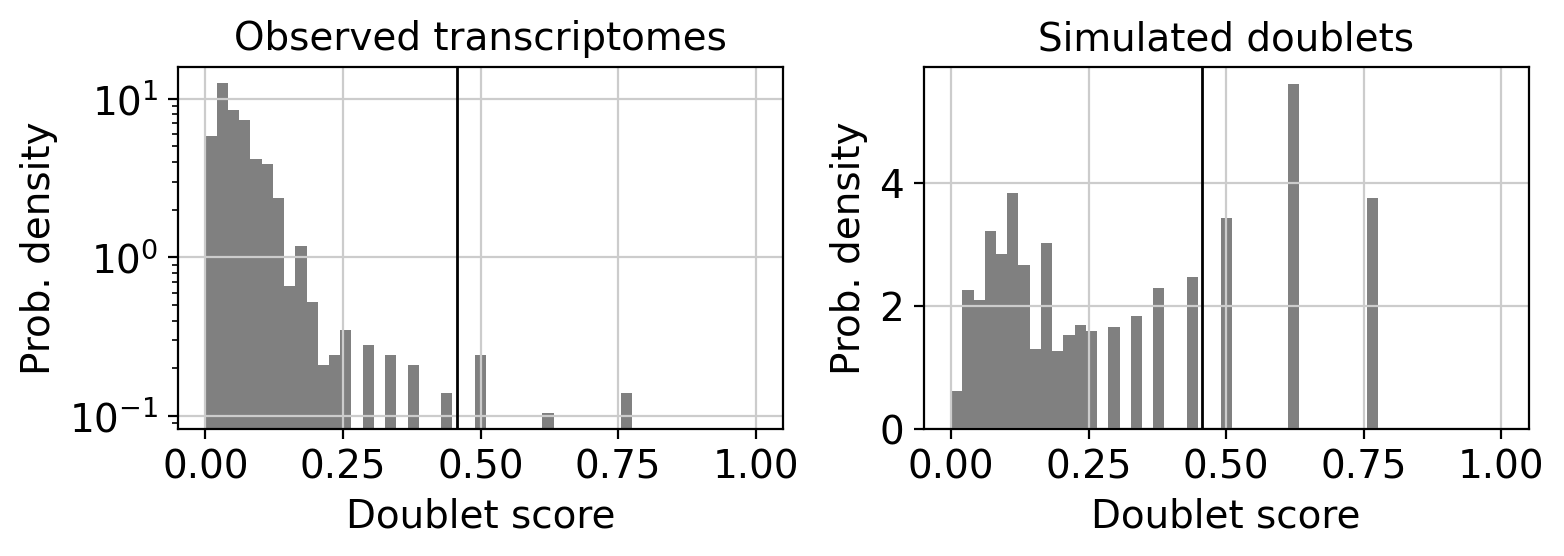

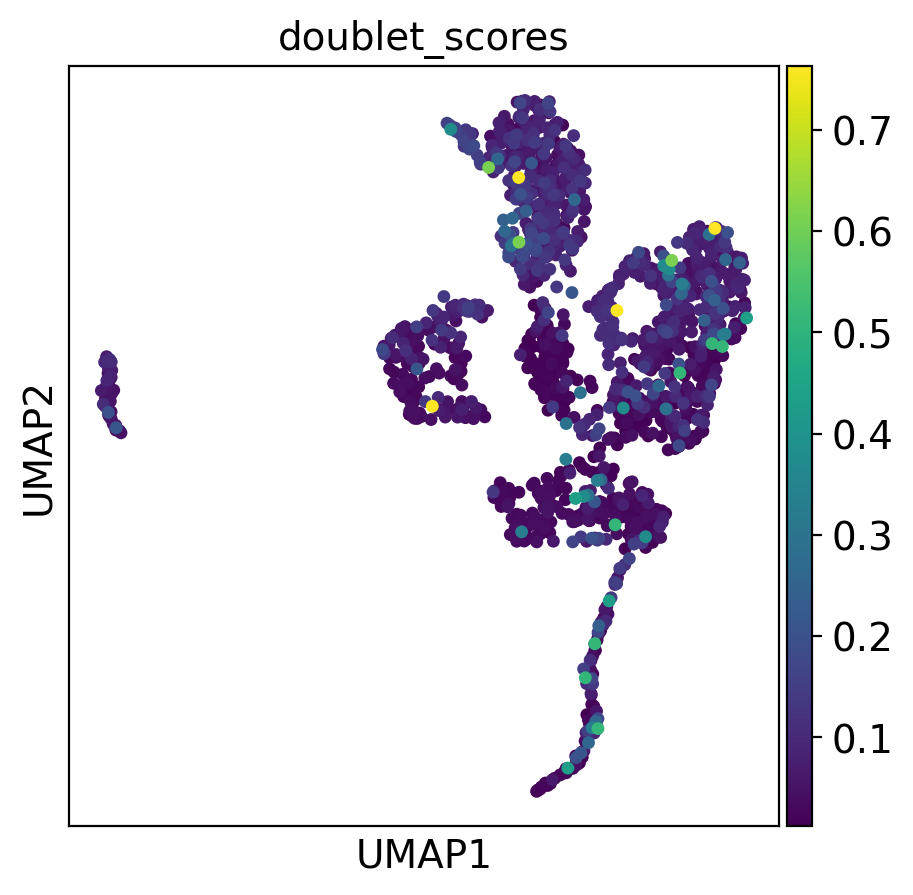

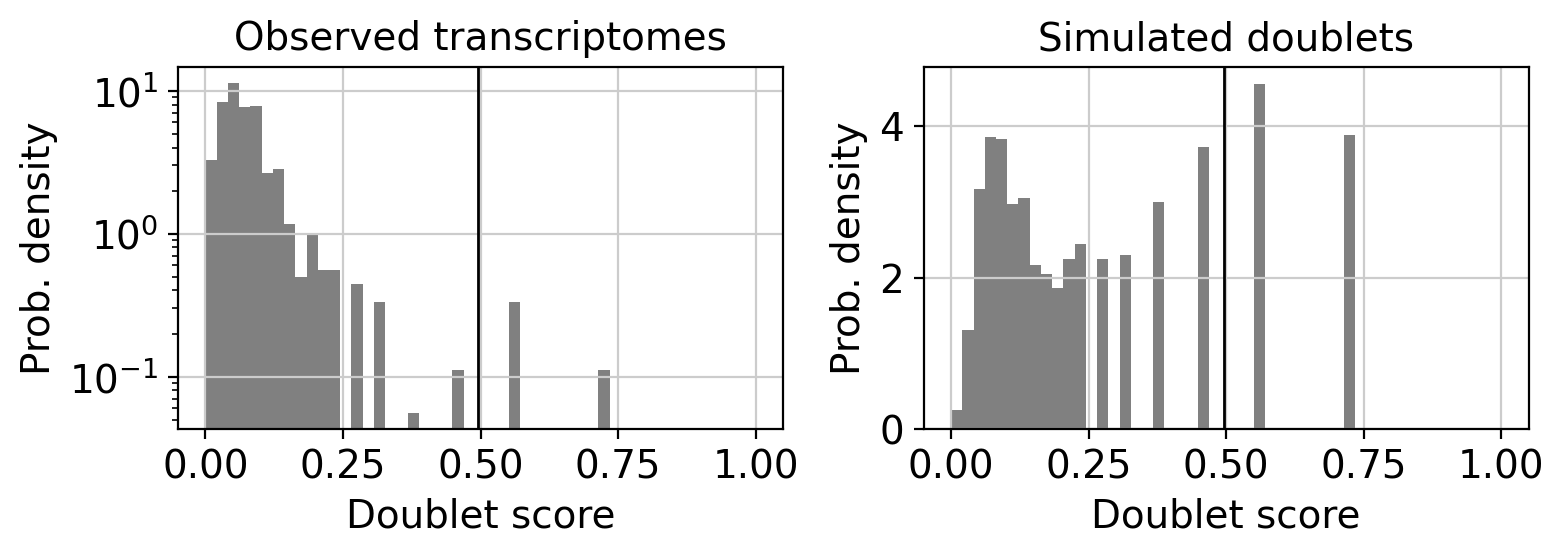

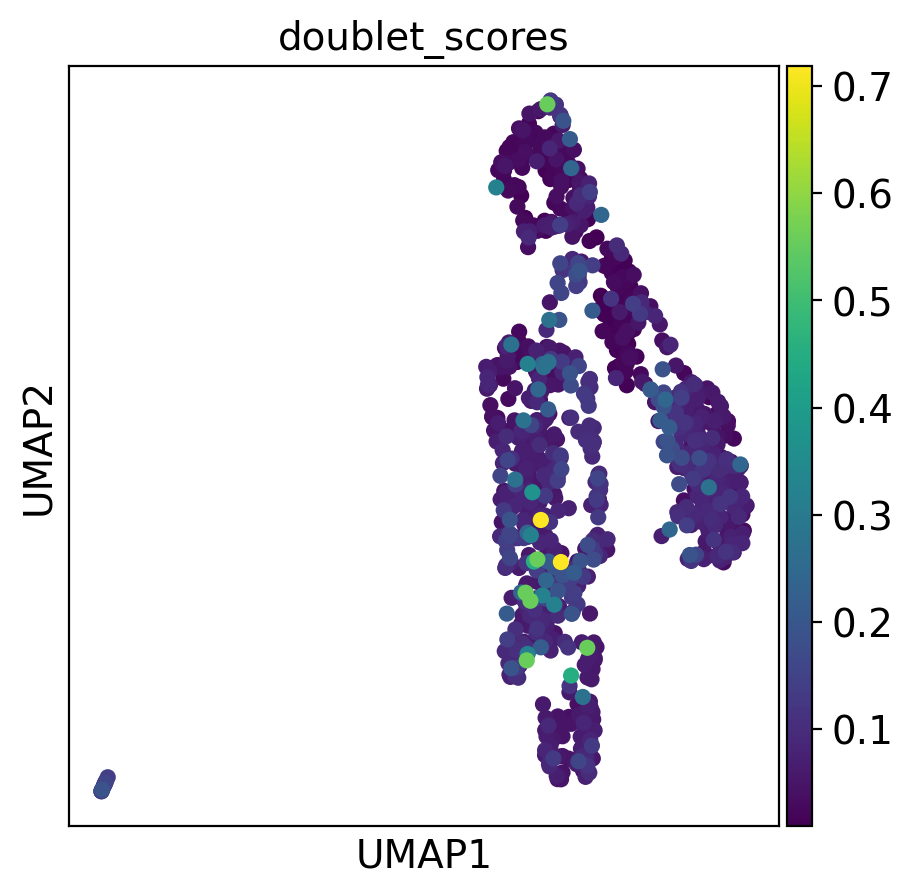

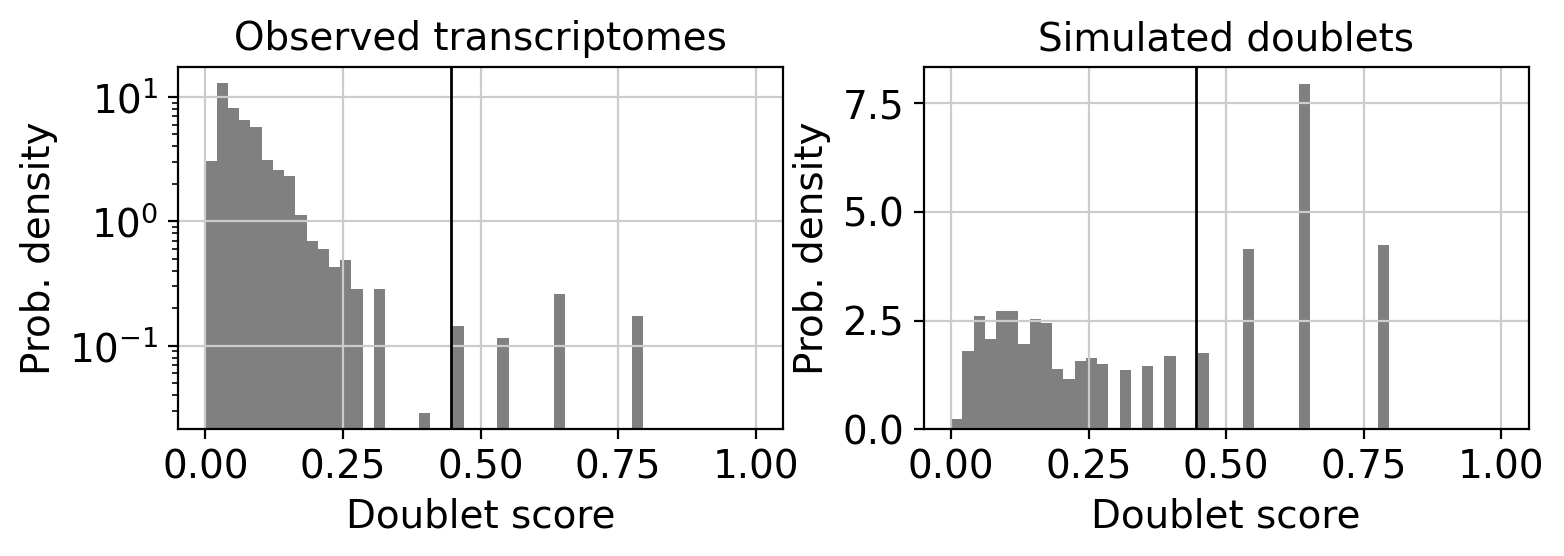

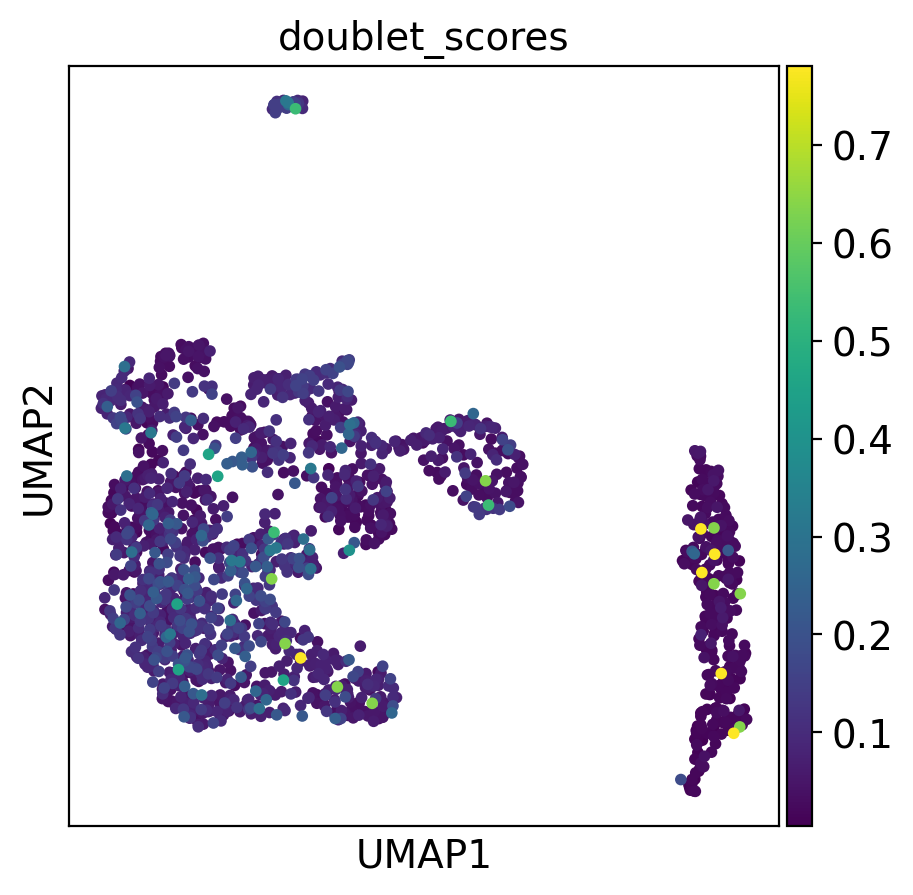

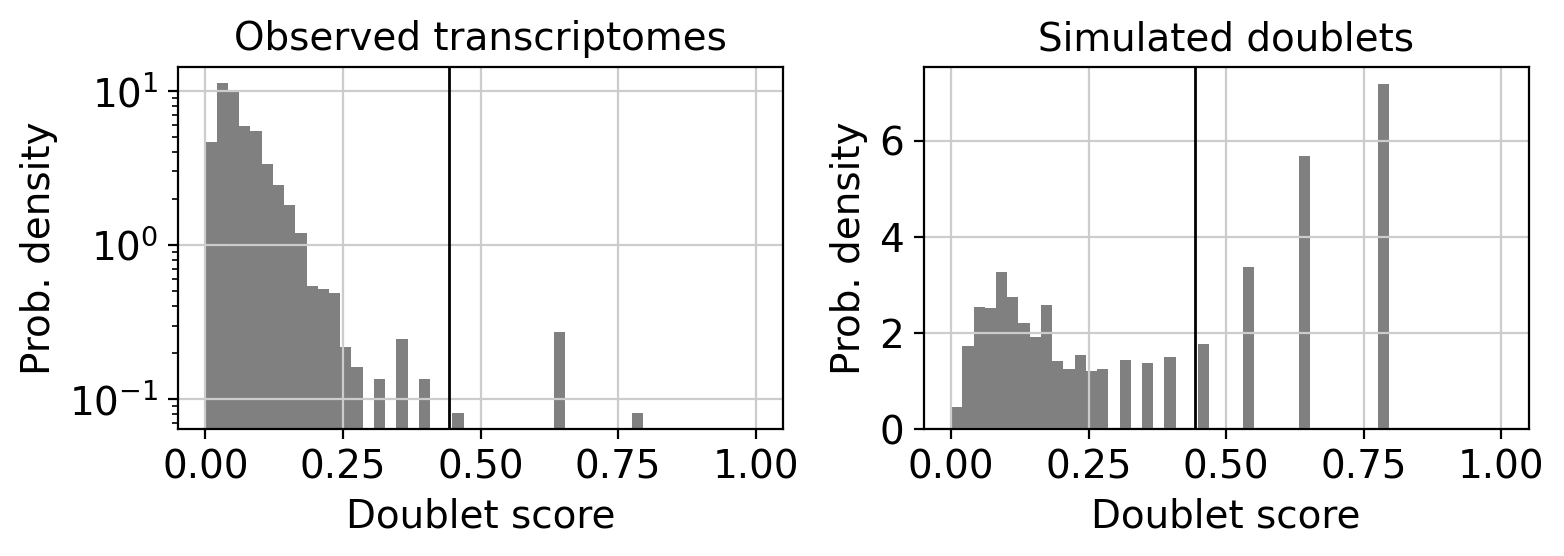

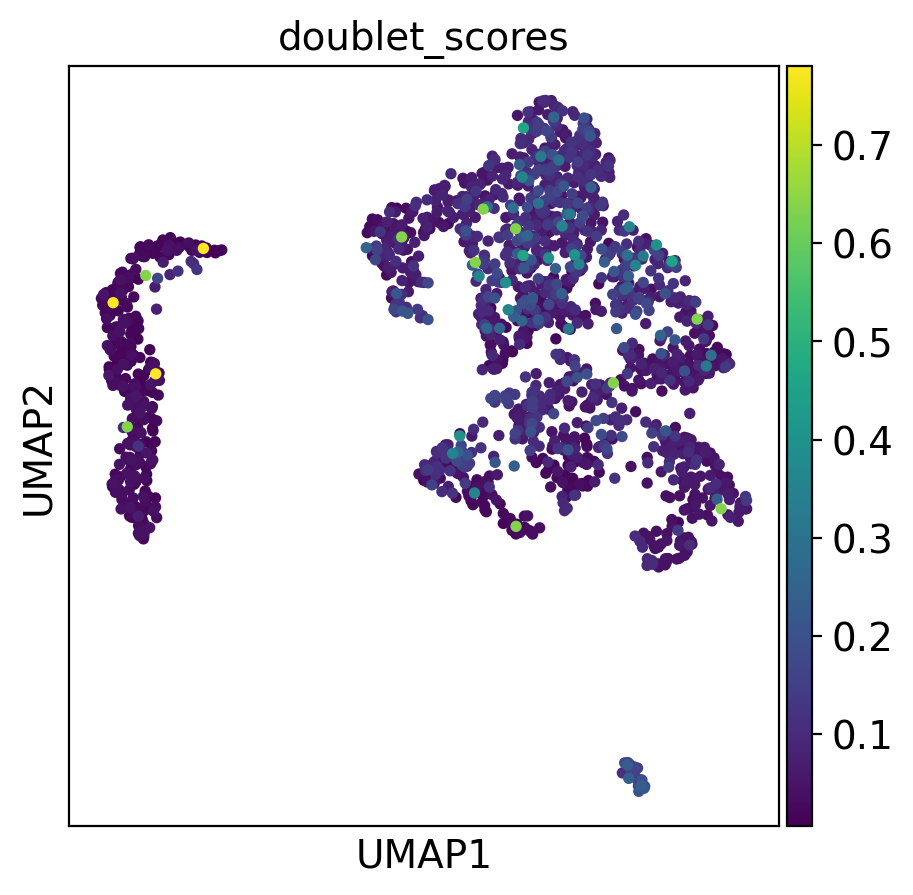

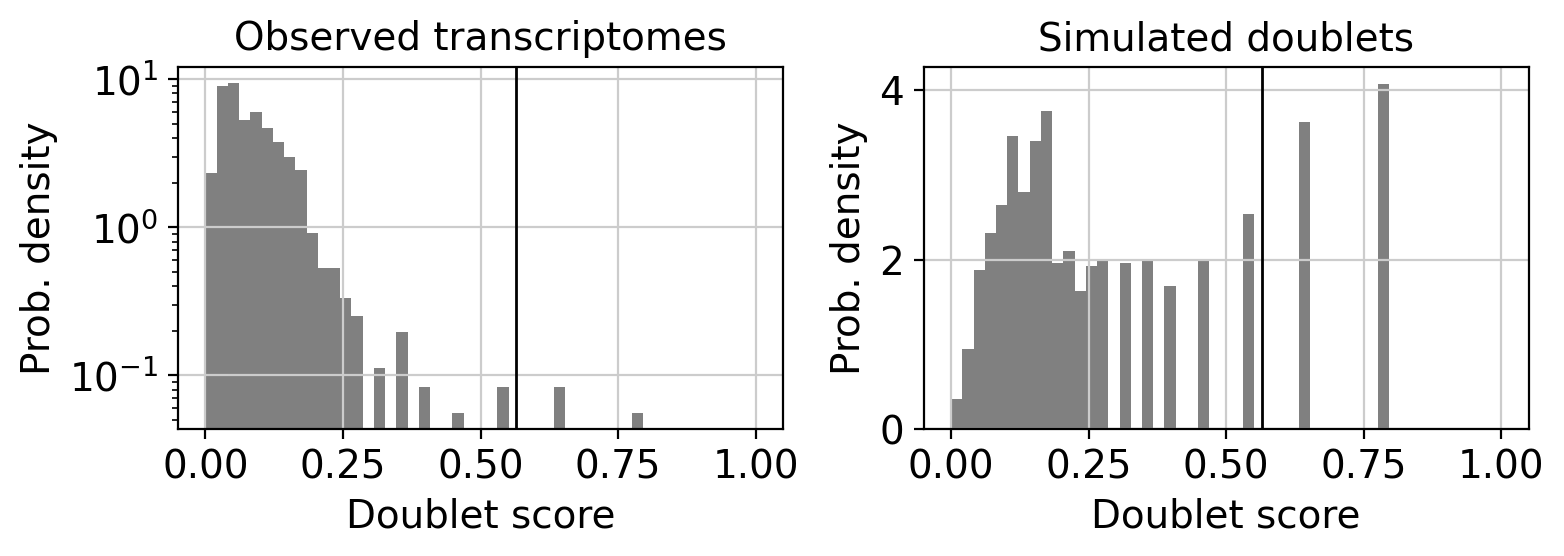

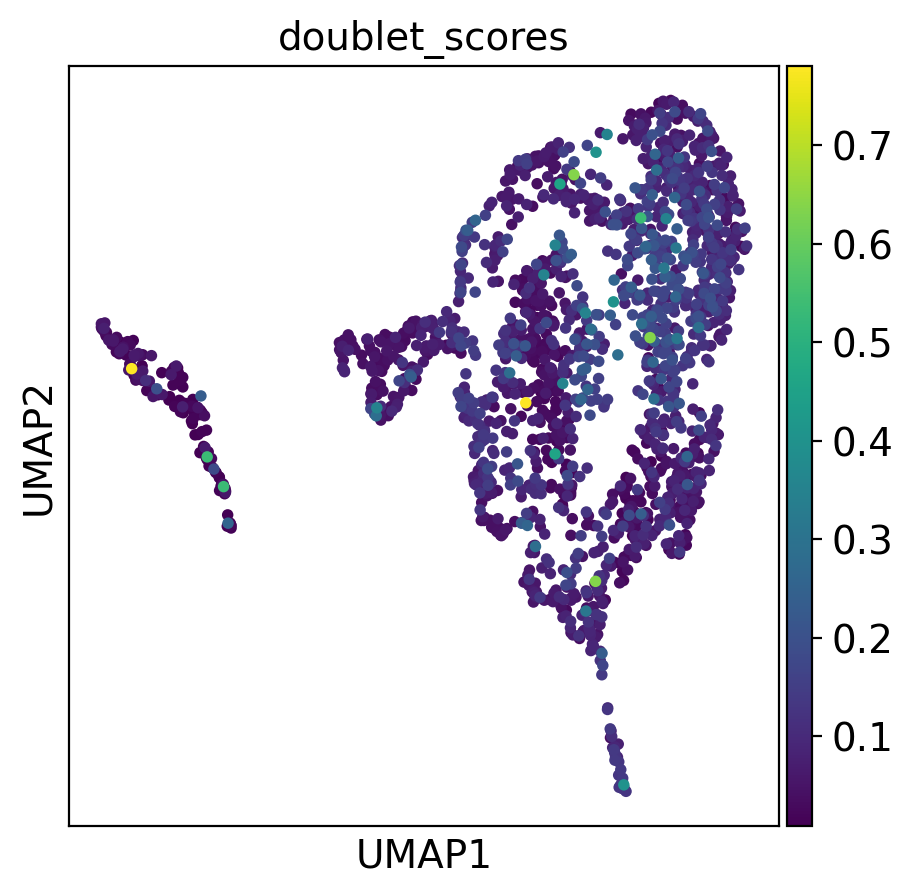

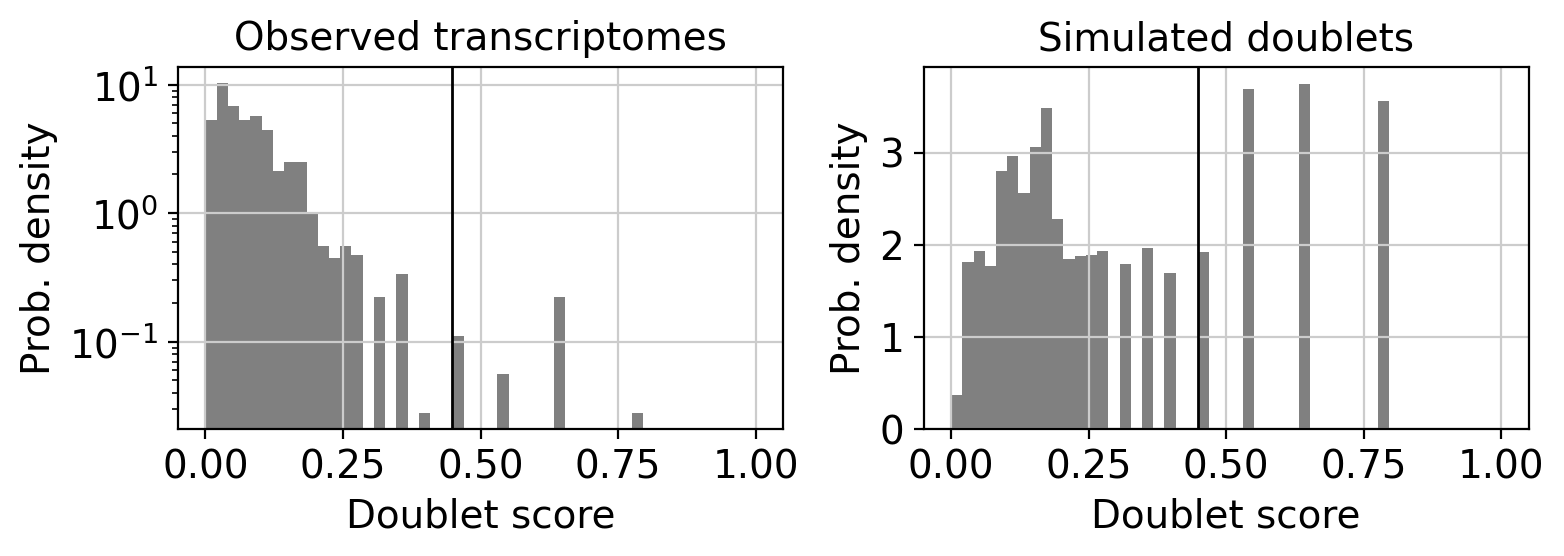

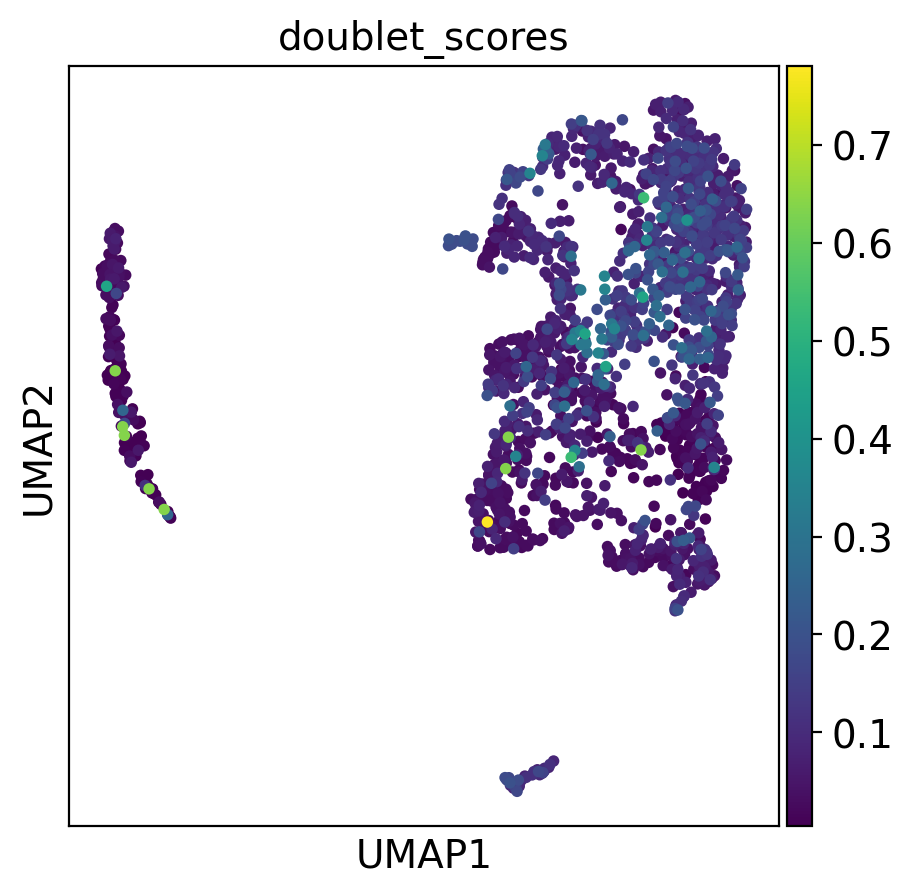

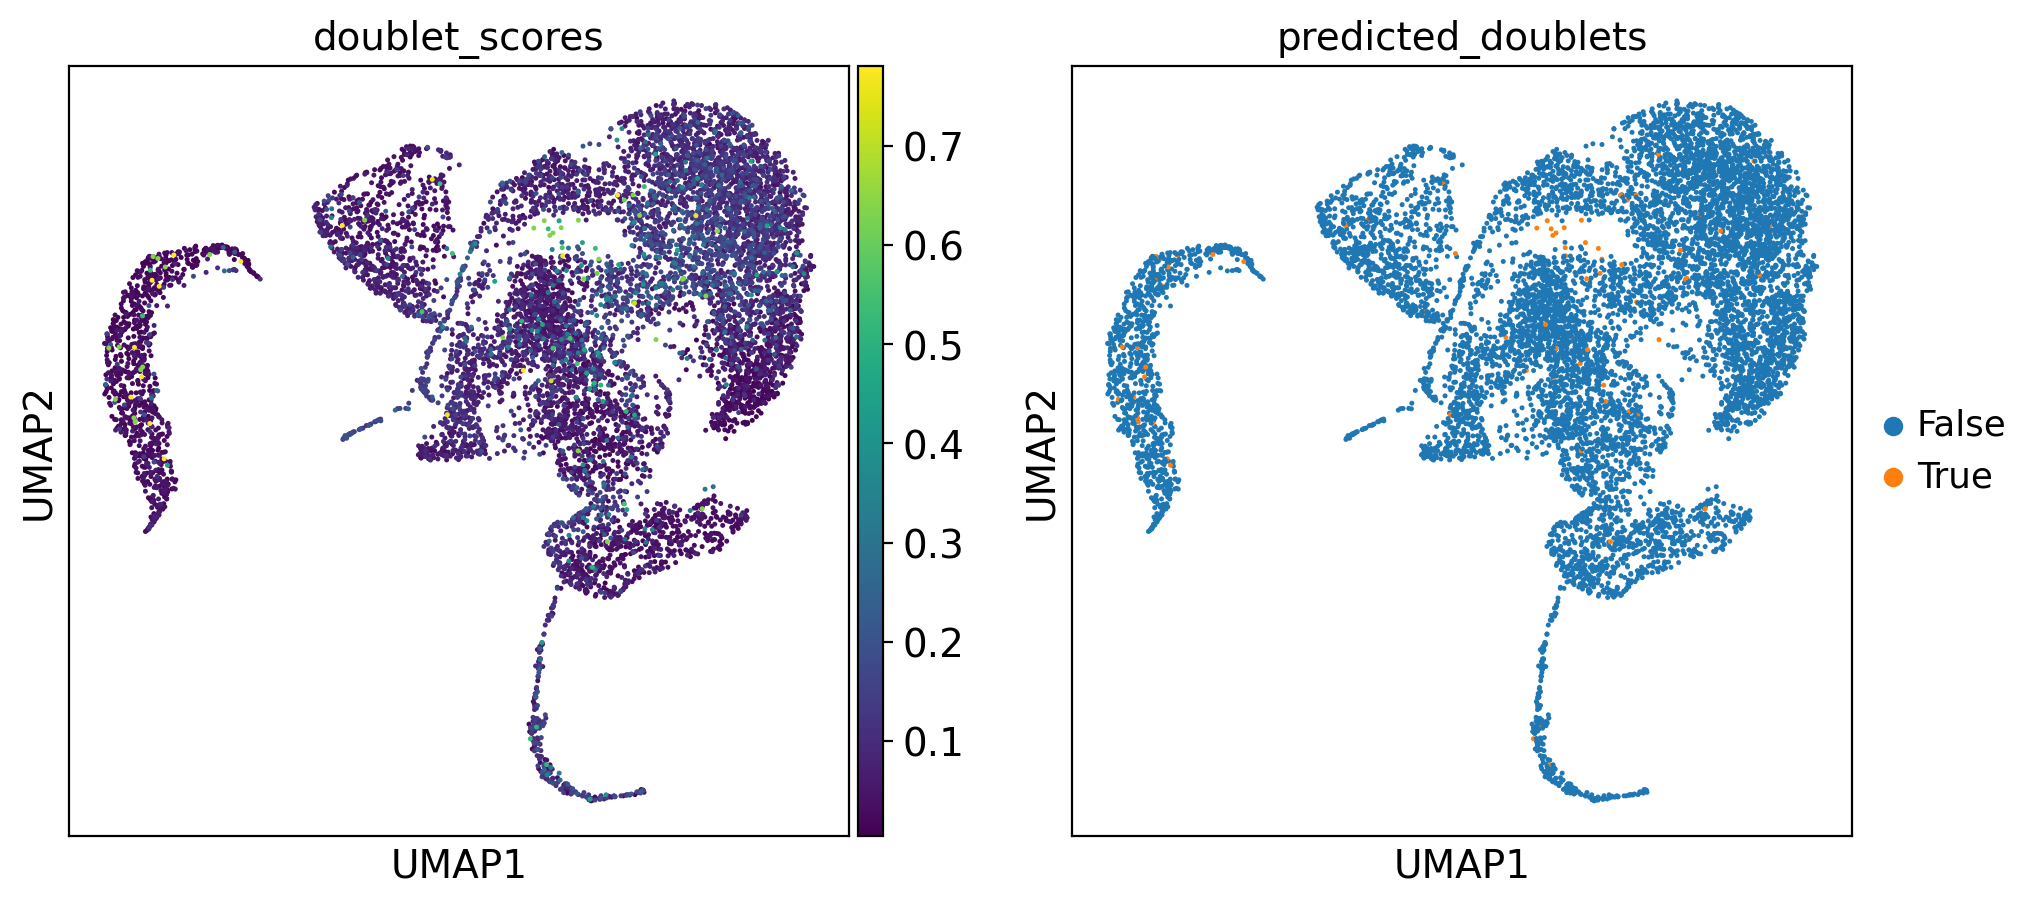

In [37]:
%matplotlib inline
sc.pp.neighbors(adata)
sc.tl.umap(adata)
adata.obs.predicted_doublets = adata.obs.predicted_doublets.astype("category") 
sc.pl.umap(adata, color=['doublet_scores','predicted_doublets'])

## remove douplets

In [40]:
print("Removed Doublets: ",len(adata[adata.obs["predicted_doublets"] == True]))

Removed Doublets:  82


In [41]:
adata = adata[adata.obs["predicted_doublets"] == False]
adata

View of AnnData object with n_obs × n_vars = 9230 × 16799
    obs: 'sample', 'batch', 'group', 'n_counts', 'percent_mito', 'n_genes', 'predicted_doublets', 'doublet_scores'
    var: 'gene_ids', 'feature_types', 'n_cells'
    uns: 'neighbors', 'umap', 'predicted_doublets_colors'
    obsm: 'X_pca', 'X_umap'
    obsp: 'distances', 'connectivities'

# Normalization and Log
using Scran

In [42]:
#Perform a clustering for scran normalization in clusters
adata_pp = adata.copy() 
sc.pp.normalize_total(adata_pp, target_sum=1e6, exclude_highly_expressed=True) 
sc.pp.log1p(adata_pp)                                                            
sc.pp.pca(adata_pp, n_comps=15)
sc.pp.neighbors(adata_pp)
sc.tl.leiden(adata_pp, key_added='communitys', resolution=0.5)

#Preprocess variables for scran normalization
input_groups = adata_pp.obs['communitys']
data_mat = adata.X.T

In [43]:
%%R -i data_mat -i input_groups -o size_factors
library(scran)
#size_factors = computeSumFactors(data_mat, clusters=input_groups, min.mean=0.1)
size_factors = sizeFactors(computeSumFactors(SingleCellExperiment(list(counts=data_mat)), 
                                             clusters=input_groups, min.mean=0.1))

/tmp/ipykernel_3909992/3972061540.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['size_factors'] = size_factors


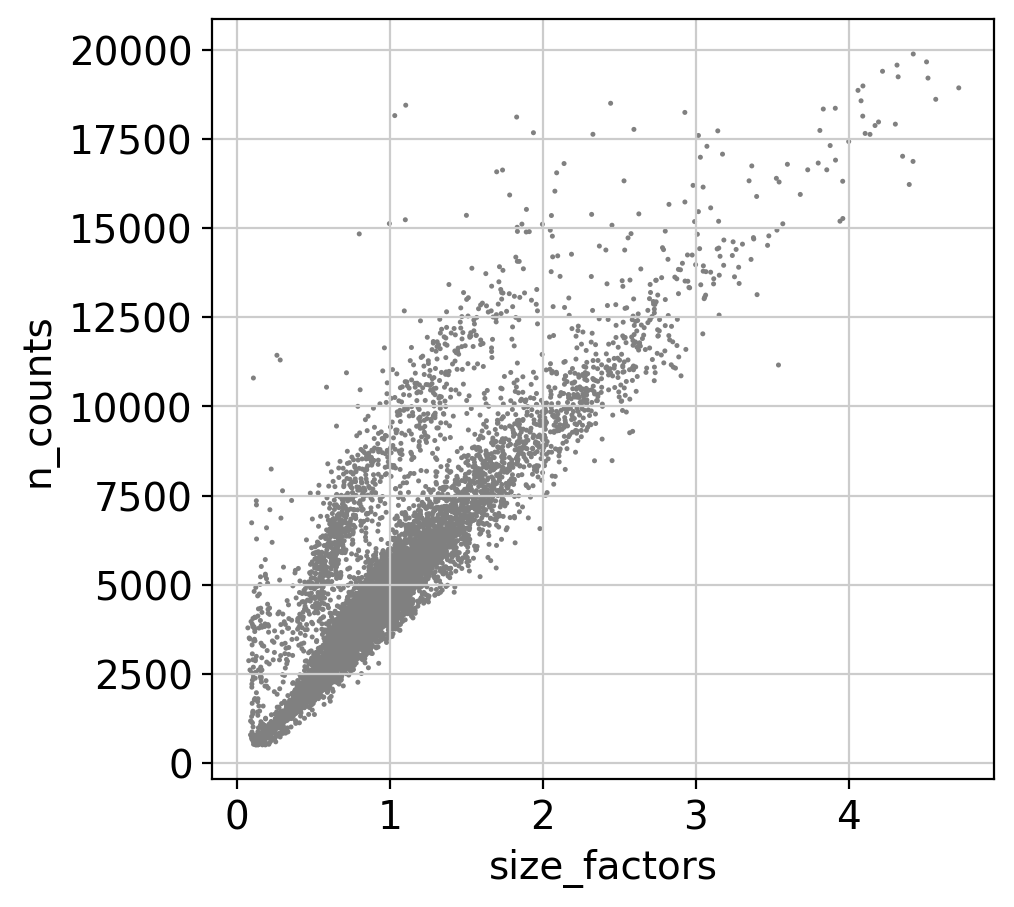

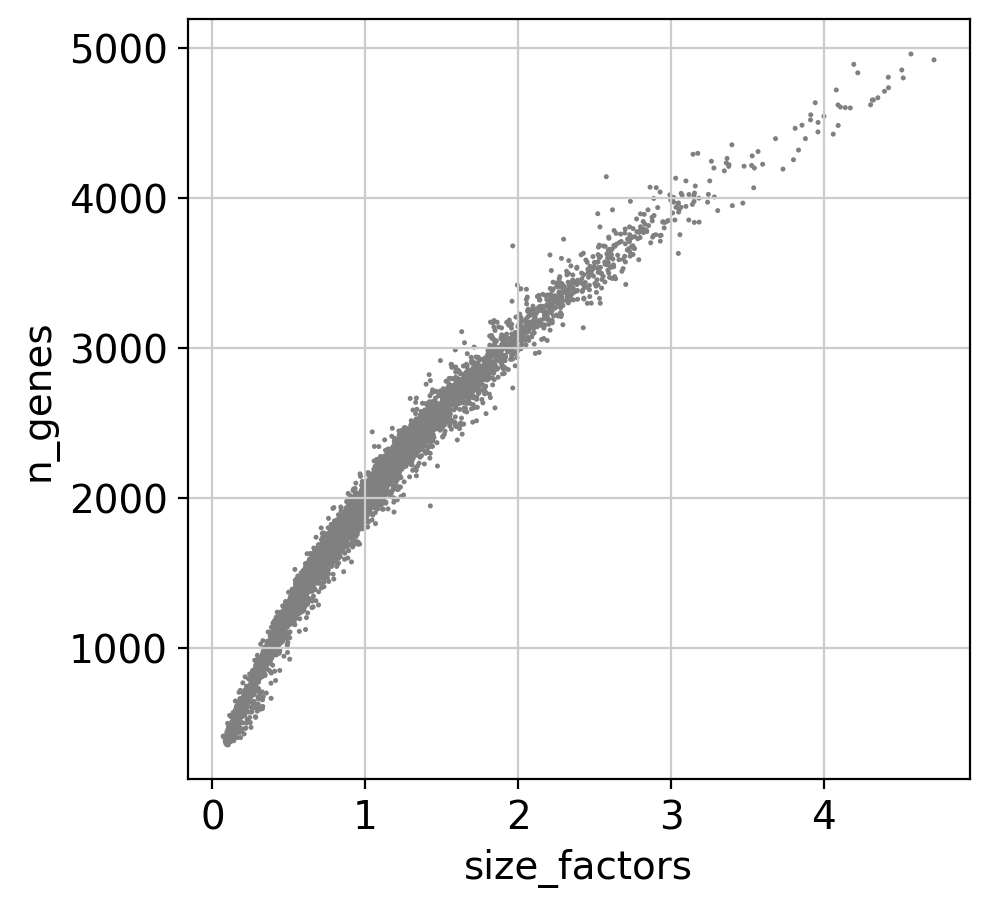

/tmp/ipykernel_3909992/3972061540.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(size_factors, bins=50, kde=False)


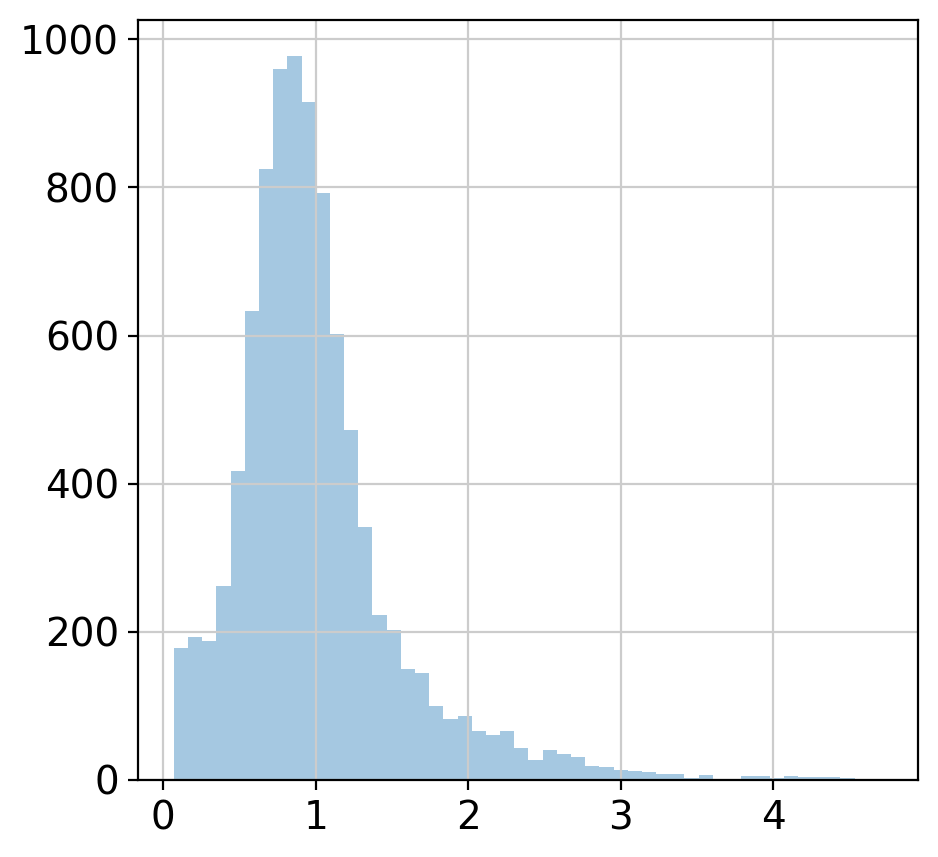

In [44]:
del adata_pp

# Visualize the estimated size factors
adata.obs['size_factors'] = size_factors
sc.pl.scatter(adata, 'size_factors', 'n_counts')
sc.pl.scatter(adata, 'size_factors', 'n_genes')
sb.distplot(size_factors, bins=50, kde=False)
plt.show()

#Keep the count data in a counts layer
adata.layers["counts"] = adata.X.copy()

#Normalize adata 
adata.X /= adata.obs['size_factors'].values[:,None]
adata.X = scipy.sparse.csr_matrix(adata.X) #convert dense back to spares
adata.nolog = adata
sc.pp.log1p(adata)

# Store the full data set in 'raw' as log-normalised data for statistical testing
adata.raw = adata #normalized and log-transformed with an offset of 1

# Batch Correction

/mnt/dzl_bioinf/exec/miniconda/miniconda3/envs/scRNA2023/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


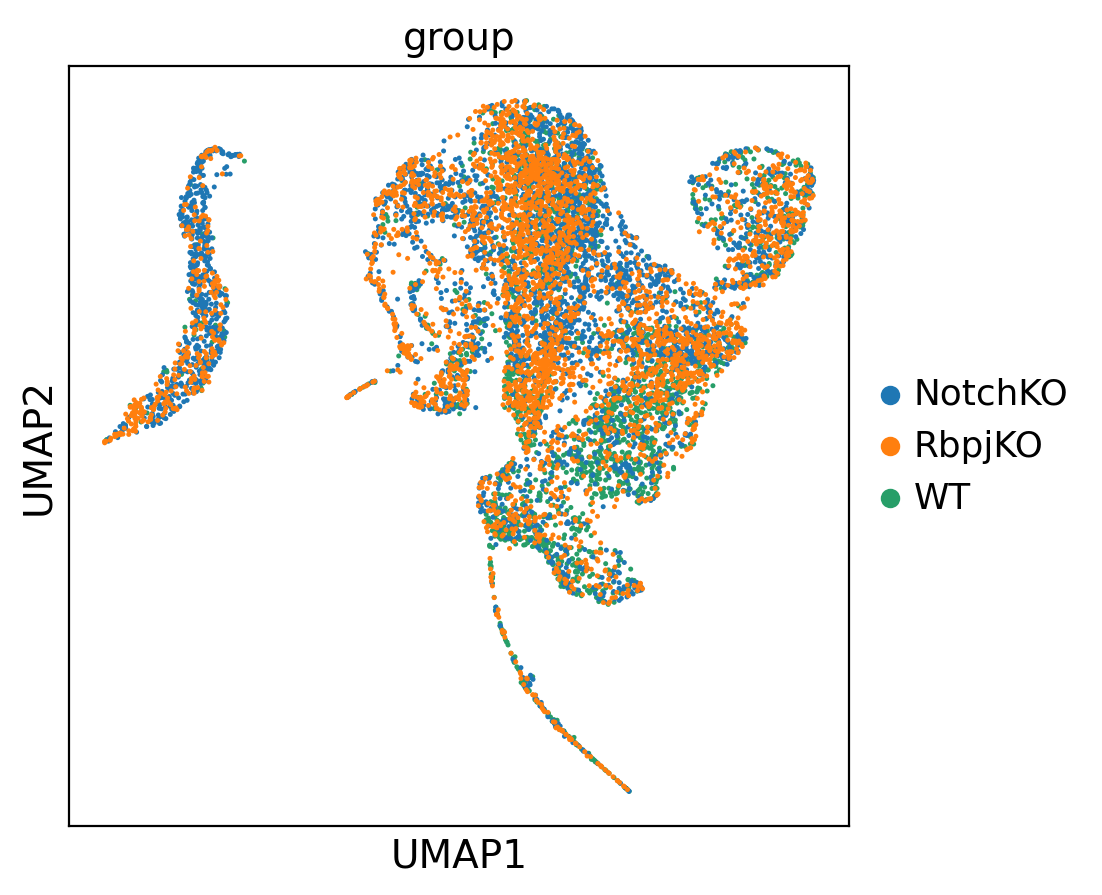

In [45]:
sc.tl.umap(adata)
sc.pl.umap(adata, color="group")

-> no clear effect  -> for now no correction

# Highl Variable Genes

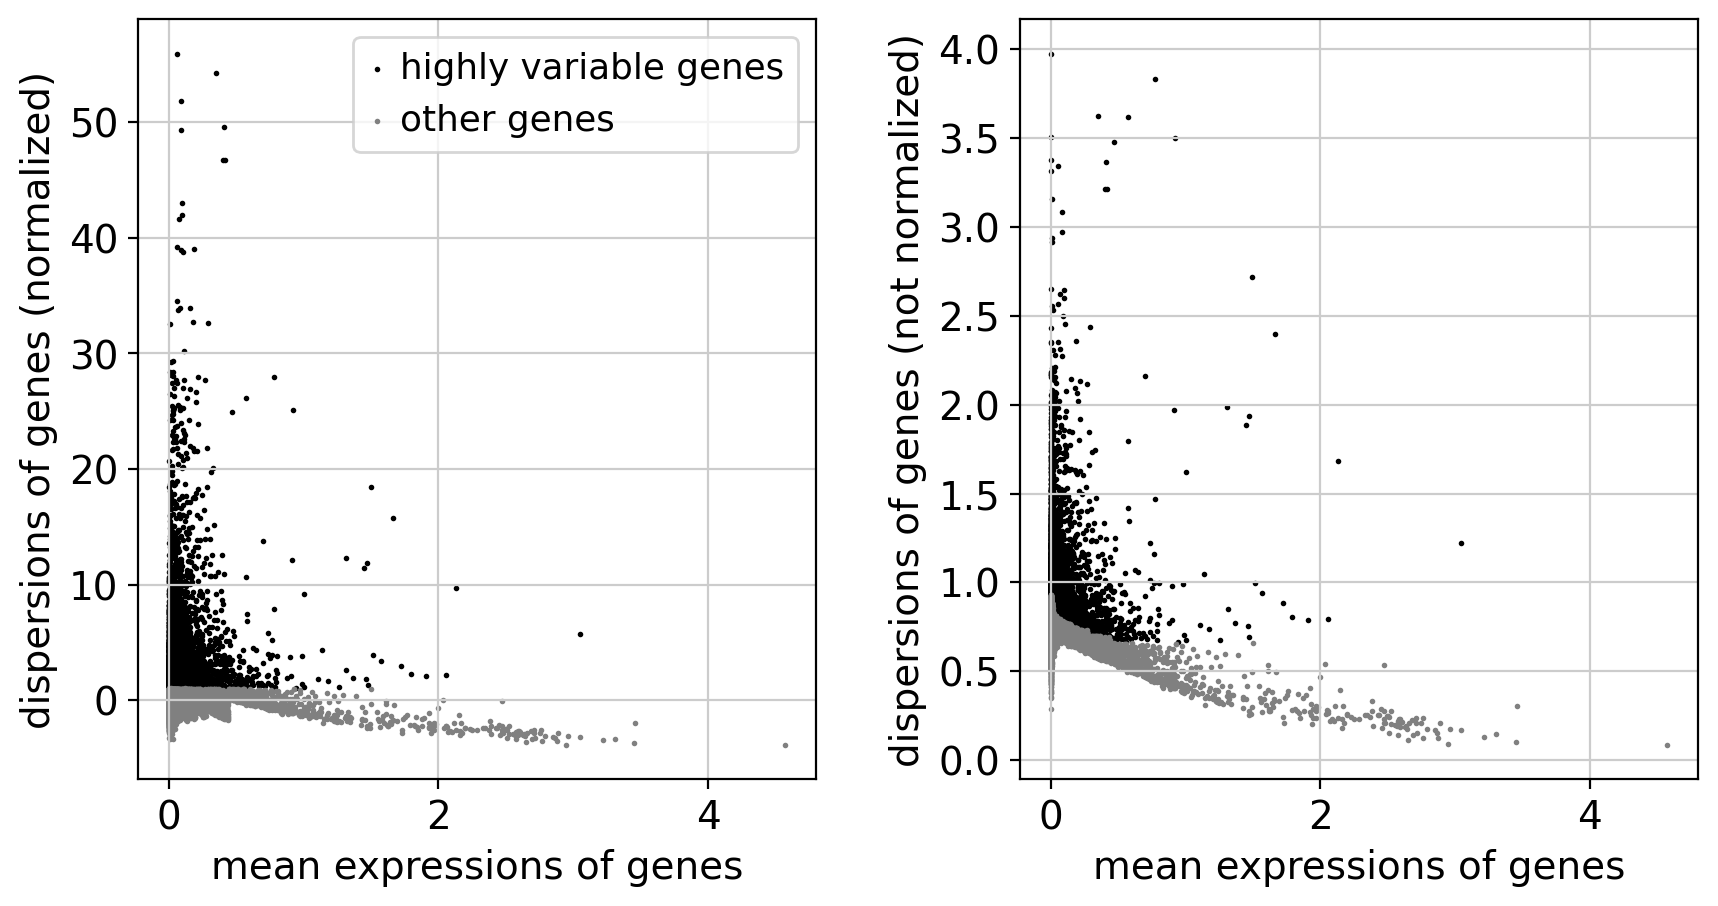

In [46]:
sc.pp.highly_variable_genes(adata, flavor='cell_ranger', n_top_genes=4000)
sc.pl.highly_variable_genes(adata)

# Clustering

In [47]:
sc.tl.leiden(adata)

In [48]:
print("nuber of cells per Leiden-Cluster")
adata.obs['leiden'].value_counts()

nuber of cells per Leiden-Cluster


0     1258
1      931
2      923
3      799
4      729
5      606
6      508
7      484
8      456
9      438
10     420
11     365
12     279
13     265
14     239
15     185
16     149
17     146
18      50
Name: leiden, dtype: int64

/mnt/dzl_bioinf/exec/miniconda/miniconda3/envs/scRNA2023/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


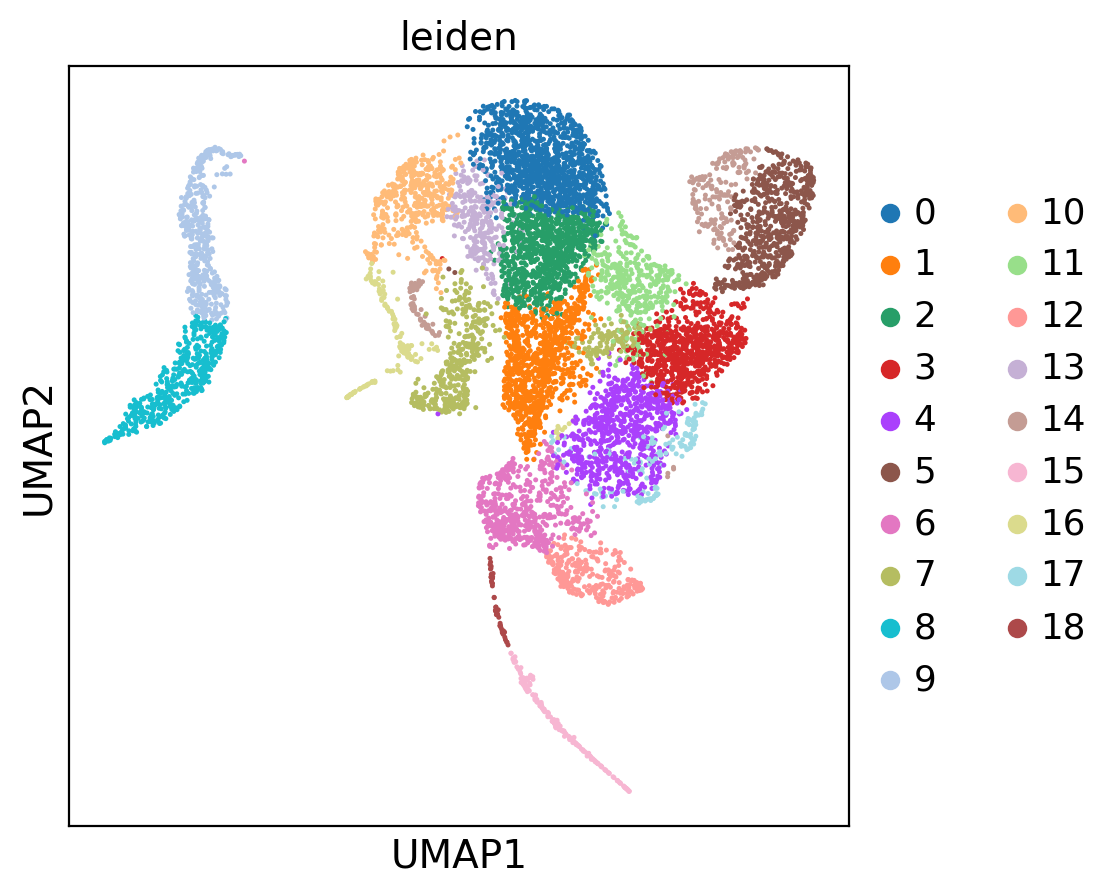

/mnt/dzl_bioinf/exec/miniconda/miniconda3/envs/scRNA2023/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


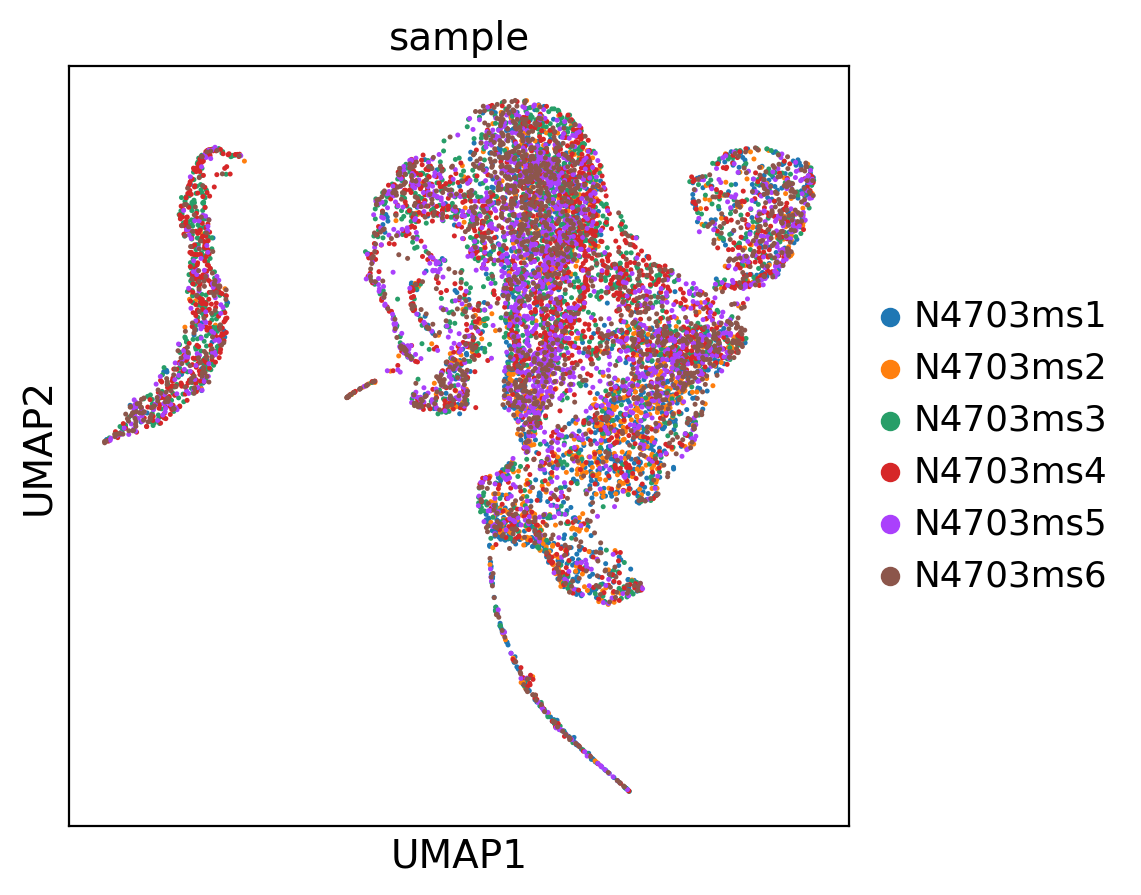

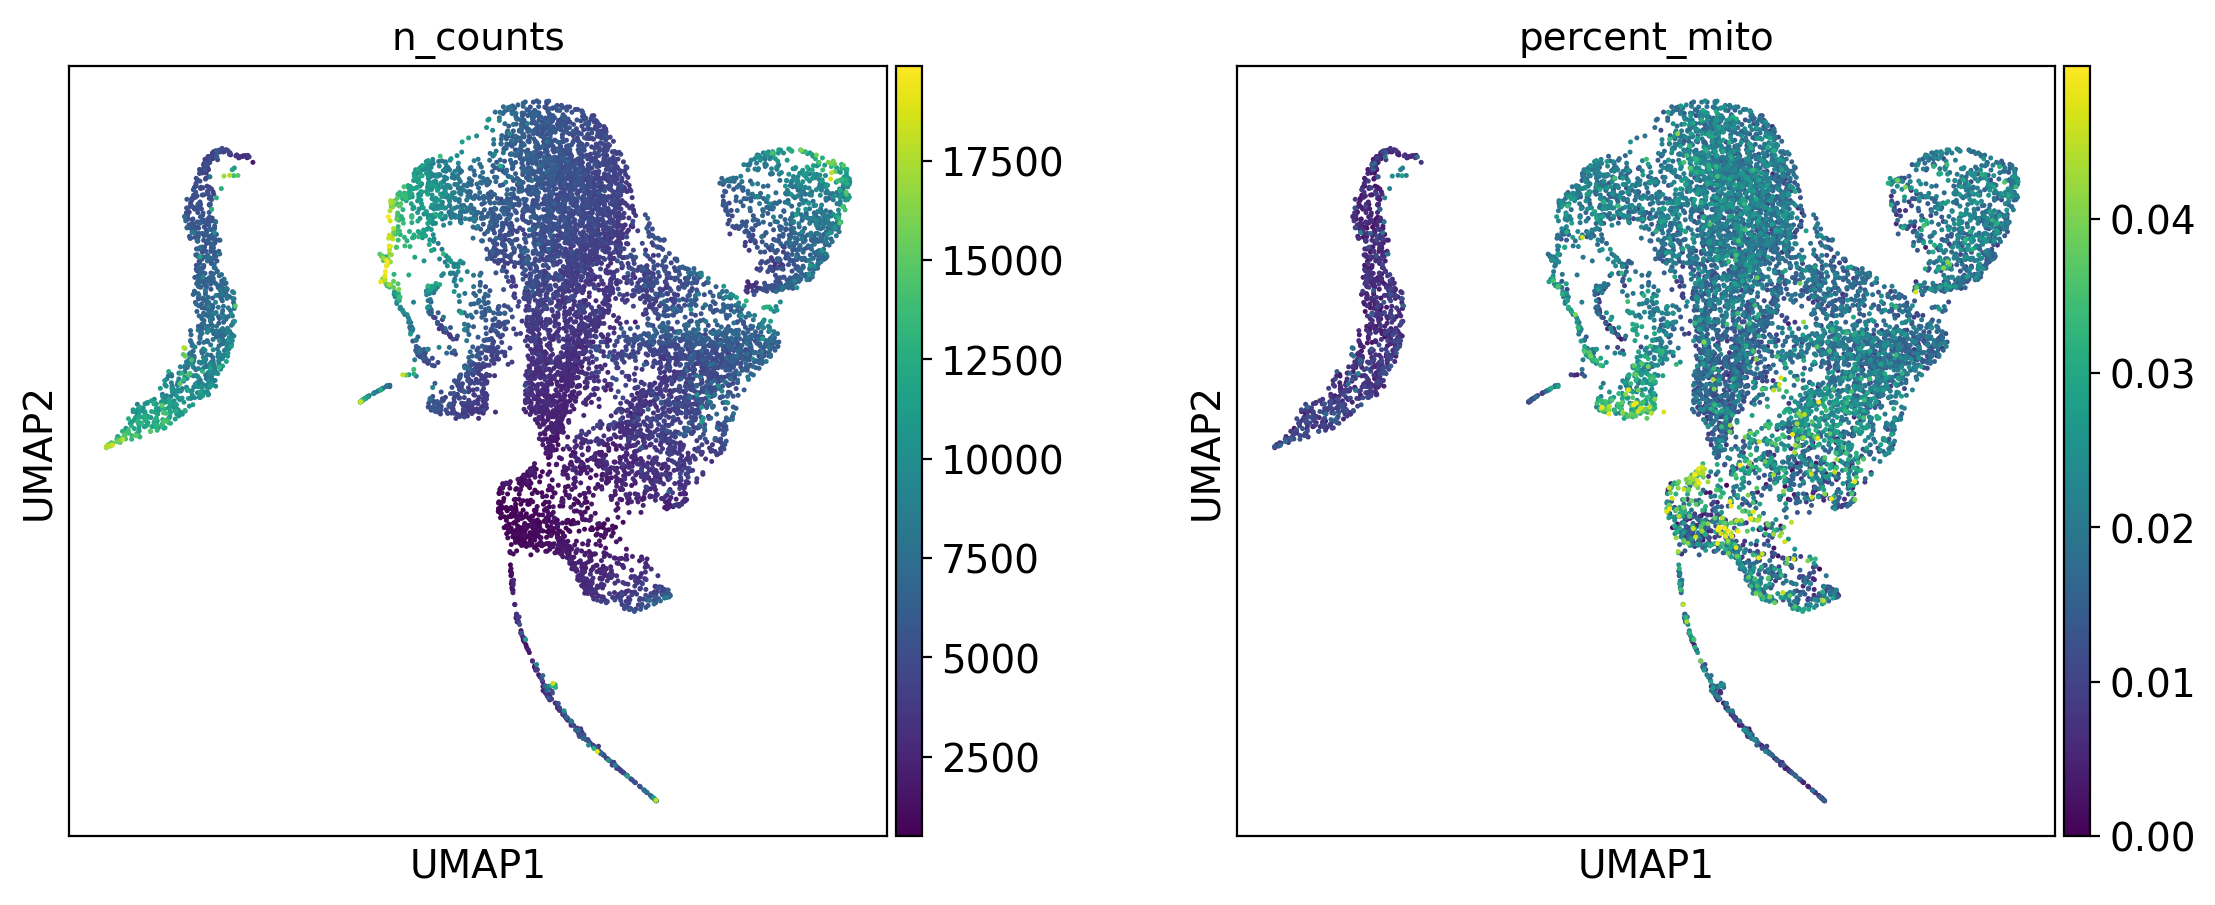

In [49]:
sc.pl.umap(adata, color=['leiden'], palette=sc.pl.palettes.default_20)
sc.pl.umap(adata, color=['sample'],wspace=0.3)
sc.pl.umap(adata, color=['n_counts', 'percent_mito'],wspace=0.3)

In [50]:
print(results_file)
adata.write(results_file)

results/scAnalyse_preprocessed_Spleen.h5ad


# save Notebook as html

In [ ]:
%%bash
jupyter nbconvert --to html Preprocessing_Spleen.ipynb
mv Preprocessing_Spleen.html ./results/Preprocessing_Spleen_$(date +%Y%m%d).html 

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
[NbConvertApp] WARNING | Config option `kernel_spec_manager_class` not recognized by `NbConvertApp`.
